


# Visión por Computador - Práctica 1 - Filtrado de Imágenes

#### 13 puntos   |   Fecha de entrega: 02 de Noviembre de 2025, 23:59   |   Forma de entrega: a través de la tarea creada en https://pradogrado2526.ugr.es/

### Estudiante: <mark>Jaime Corzo Galdó</mark>



---

## Normas de desarrollo y entrega de la práctica

1. Para este trabajo, al igual que para los demás, se debe presentar código, resultados, discusión de los mismos, y presentación y análisis del trabajo realizado, todo integrado en el propio Google Colab Notebook (es decir, no se entrega ninguna memoria separada en `.pdf` ni ningún código `.py`). Se recuerda que código y resultados sin informe explicativo no puntúa. Resulta también fundamental recordar que solo se acepta la entrega de ficheros `.ipynb` (no resulta válido entregar un fichero `.py`).

2. En relación con el punto anterior, se recuerda que se proporciona un Notebook, denominado `Ejemplo_Otsu.ipynb`, que muestra un ejemplo de respuesta y solución a un potencial ejercicio. El propósito de este Notebook es servir de referencia al alumnado acerca de cómo responder los ejercicios planteados. Véase que, por ejemplo, en aras de diferenciar con facilidad enunciados y respuestas, estas últimas se presentan en otro color (azul, en ese caso).

3. El diseño de celdas del documento debe ser respetado. Es decir, no se puede modificar el orden de los ejercicios o alterar la estructura del Notebook, de forma que dificulte localizar los contenidos. Aunque sí se puede, por ejemplo, crear nuevas subsecciones dentro de las secciones ya existentes para estructurar y organizar con más claridad las respuestas, así como para incluir los experimentos extra que se deseen.

4. Tal y como se muestra en `Ejemplo_Otsu.ipynb`, no hay ningún problema en emplear técnicas de IA generativa (como ChatGPT o Gemini) para crear el código de los distintos ejercicios o para enriquecer el análisis y descripción del trabajo realizado (aunque, obvia decirlo, su uso no es obligatorio). Pero, en caso de usarse, sí se debe aclarar de qué modo se ha usado la IA, con qué objetivo, y se debe demostrar que se entiende perfectamente lo que se ha hecho.

5. Solo se entregará el fichero `.ipynb` (incorporando código, resultados, y explicación del trabajo realizado y los resultados obtenidos) y no se enviarán las imágenes empleadas. El path para la lectura de imágenes, o cualquier otro fichero de entrada, debe ser siempre “/content/drive/My Drive/images/nombre_fichero”.

6. El código deberá  presentarse adecuadamente comentado y con los resultados obtenidos en cada apartado, junto con la presentación del trabajo realizado y la discusión y análisis de los resultados obtenidos. Es importante reiterar que la entrega de código sin informe explicativo o valoraciones no puntúa. Por otro lado, el código debe ir comentado en comentarios en celdas de código, mientras que el análisis y discusión, tanto del trabajo realizado como de los resultados obtenidos, debe ir en celdas de texto.

Este trabajo de implementación tiene como objetivo principal **familiarizarse con la implementación y uso de filtros de convolución, así como del cálculo de las derivadas de una imagen y sus posibles aplicaciones**.




### Materiales de Apoyo

En caso de que el alumnado tenga dudas sobre Python, OpenCV o el uso de Google Colab, se recuerda que en PRADO hay materiales de apoyo (https://pradogrado2526.ugr.es/mod/folder/view.php?id=95307):
-  Introducción a Python: https://pradogrado2526.ugr.es/pluginfile.php/243163/mod_folder/content/0/1.%20Introduccion%20a%20Python.pdf
- Introducción a NumPy, Matplotlib y Scikit-learn: https://pradogrado2526.ugr.es/pluginfile.php/243163/mod_folder/content/0/2.%20Introducción%20a%20Numpy%20Matplotlib%20y%20sklearn.pdf
- Notebook con toda la información anterior (y más cosas): https://pradogrado2526.ugr.es/pluginfile.php/243163/mod_folder/content/0/Guia_Python.ipynb
- Ejercicios y ejemplos de repaso: https://pradogrado2526.ugr.es/pluginfile.php/243163/mod_folder/content/0/3.%20Ejercicios%20y%20ejemplos%20de%20repaso.pdf
- Fundamentos de Python para lectura, visualización y manipulación de imágenes: https://pradogrado2526.ugr.es/pluginfile.php/243163/mod_folder/content/0/4.%20Fundamentos%20de%20Python%20para%20manipulacion%20de%20imagenes.pdf (y Notebook asociado: https://pradogrado2526.ugr.es/pluginfile.php/243163/mod_folder/content/0/Guia_fundamentos_imagenes.ipynb)
- Ideas sobre cómo redactar un documento académico-científico (útil para saber cómo documentar las respuestas a los ejercicios, el Notebook en su conjunto, y la memoria del proyecto final o de un TFG/TFM): https://pradogrado2526.ugr.es/pluginfile.php/243163/mod_folder/content/0/Algunas%20ideas%20sobre%20cómo%20elaborar%20un%20informe%20académico-científico.pdf
- Ejemplo de respuesta a un hipotético ejercicio sobre el algoritmo de umbralización de Otsu: https://pradogrado2526.ugr.es/pluginfile.php/243164/mod_folder/content/0/Ejemplo_Otsu.ipynb



---



## Funciones de apoyo y conexión con Google Drive

In [ ]:
# We start by getting access to the drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
# We import the main potential modules to use
import os,sys
import cv2, numpy as np, math
from matplotlib import pyplot as plt
# change directory
%cd '/content/drive/My Drive'
#  the current directory
%pwd

# This allows to display images  and to save  them in cells
%matplotlib inline
# this definition allows to read files in a specific path
get_image = lambda route: os.path.join('/content/drive/My Drive/images', route)

/content/drive/My Drive


Las funciones que se incluyen a continuación, se proporcionan como ayuda/apoyo para el estudiante. **En caso de que el alumnado prefiera utilizar otras funciones para lectura, normalización y visualización de imágenes, tiene total libertad para hacerlo, pero sí debe justificar y explicar razonadamente el motivo de dicho cambio y describir las modificaciones realizadas.**

Recuérdese que todas las imágenes a emplear durante las prácticas de todo el curso se pueden encontrar en el enlace de Google Drive indicado en PRADO: https://pradogrado2526.ugr.es/mod/url/view.php?id=95306 En concreto, https://drive.google.com/drive/folders/1UtvY8q6w1Cz9a9T9zxIqSweoRLgNwoW-

In [ ]:
'''
This function receives a string with the filename of the image to read,
and a flag indicating if we want to read it in color/RGB (flagColor=1) or gray level (flagColor=0)

Example of use:
im1=readIm(get_image('apple.jpg'),0)

'''
def readIm(filename, flagColor=1):
  # cv2 reads BGR format
  im=cv2.imread(filename)
  # change to  RGB and return the image
  if(flagColor):
    return cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
  # change from BGR to grayscale instead if flag is 0
  return cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)

In [ ]:
'''
This function receives an array of arbitrary real numbers (that could include even negative values),
and returns an 'image' in the range [0,1].
flag_GLOBAL allows the user to normalize the whole image (including all channels) or to normalize
each channel/band independently.
'''
def rangeDisplay01(im, flag_GLOBAL= True):
  im = im.astype(float)
  if flag_GLOBAL:
    im = (im - im.min())/(im.max() - im.min())
  else:
    # bands normalization
    for band in range(im.shape[2]):
      im[:, :, band] = (im[:, :, band] - im[:, :, band].min())/(im[:, :, band].max() - im[:, :, band].min())
      # Note: remember that, for plt.imshow with RGB data, the valid range is [0..1] for floats and [0..255] for integers.
  return im

In [ ]:
'''
This function displays a single image, including a title, using a magnification factor.

Example of use:
im1=readIm(get_image('apple.jpg'),0)
displayIm(im1,'Manzana',0.5)

'''
def displayIm(im, title='Result',factor= 2):
  # First normalize range
  max=np.max(im)
  min=np.min(im)
  if min<0 or max>255:
    im=rangeDisplay01(im,flag_GLOBAL=True)
  if len(im.shape) == 3:
    # im es tribanda
    plt.imshow(im, cmap='jet')
  else:
    # im es monobanda
    plt.imshow(im, cmap='gray')
  figure_size = plt.gcf().get_size_inches()
  plt.gcf().set_size_inches(factor * figure_size)
  plt.title(title)
  plt.xticks([]), plt.yticks([]) # eliminamos numeración
  plt.show()

In [ ]:
'''
This function displays multiple images (including a title and using a magnification factor)
of equal size. The input to the function is a list of images.

Example of use:
im1=readIm(get_image('apple.jpg'),1)
images = [im1,im1,im1]

displayMI_ES(images, title='Manzanas',factor=1)

IMPORTANT NOTE: it is important to notice that this function stacks all images
and later call displayIm(). This implies that the normalization (rangeDisplay01()) is done
at the very end of the process. As a consequence, if the stacked images have different
range values they can be displayed in a "weird" way (with black regions (pixel value = 0)
looking grey). In case the visualization seems to be a problem, a possible solution
would be to create vim using vim.append(rangeDisplay01(...)). In this way, all images
would be on the same range of values (negative values around 0 (black),
0 values around 0.5 (grey), and positive values closer to 1 (white))

'''
def displayMI_ES(vim, title='Result',factor=2):
  # We set the maximun number of images to concatenate by columns
  maxcolumns=3
  # number of images to display
  numberim=len(vim)
  # The simplest case, one row: the maximum number of columns is larger than the images to stack
  # This is, by default, we put together the images column-wise
  if len(vim) < maxcolumns:
    out=vim[0]
    for item in range(1,len(vim)):
      #displayIm(out,str(item),1)
      out=np.hstack((out,vim[item]))

  # Else, if maxcolumns is smaller or equal than the number of images to stack
  else:
    # We check if all rows and columns are going to be 'busy', or if otherwise we need an extra-row
    if np.mod(len(vim),maxcolumns)== 0:
      maxrows=numberim//maxcolumns
    else:
      maxrows=numberim//maxcolumns+1

    # we build up the first block-row
    out=vim[0]
    for item in range(1,maxcolumns):
      out=np.hstack((out,vim[item]))
    # We build up the rest of block-rows
    for block in range(1,maxrows):
      #print(block)
      row=vim[block*maxcolumns]
      for item in range(1,maxcolumns):
        # We still have images to stack
        if block*maxcolumns+item < numberim:
          row=np.hstack((row,vim[block*maxcolumns+item]))
        # We do not have more images, and we have to fill with black
        else:
          row=np.hstack((row,np.zeros(vim[0].shape,dtype=vim[0].dtype)))
          #print(row.dtype)
          # if we don't include ',dtype=vim[0].dtype', np.zeros will include float
          # numbers in the matrix. This will make that the whole matrix will be
          # considered as floats, and values larger than 1 will be clipped to 1,
          # displaying an almost totally white image
      # add the new block-row
      out=np.vstack((out,row))
  return displayIm(out,title,factor)

# **Ejercicio 1: discretización de máscaras y filtrado Gaussiano** (5.5 puntos)

En este ejercicio aprenderemos a discretizar máscaras de convolución y a aplicarlas sobre imágenes empleando funciones de OpenCV. También buscamos hacerlo de un modo eficiente, y es por ello que, en toda la práctica, se exige el uso de convoluciones 1D (separables).





## A) (1.5 puntos)

En este apartado se deben realizar las siguientes tareas:

1. Calcular las máscaras discretas 1D de la Gaussiana, así como su primera y segunda derivadas (normalizadas), considerando que la entrada a dicha función de creación de máscaras 1D puede ser tanto un posible sigma como un posible tamaño de máscara.
2. Emplear los siguientes valores de sigma ($\{0.75, 1.5, 3, 6, 12\}$) y los siguientes valores de tamaño de máscara ($\{5,9,11,15\}$), y mostrar el perfil (es decir, la silueta de las máscaras como funciones 1D) para verificar que las máscaras creadas son correctas.
3. Describir/explicar/analizar si las formas de dichos kernels tienen sentido y se corresponden con lo que esperaríamos ver.

<font color="blue">Para resolver este ejercicio primero teniamos que calcular las expresiones analíticas de la gaussiana, y sus dos primeras derivadas, y hemos obtenido lo siguiente:

<font color="blue">\begin{equation}
G(x,\sigma) = e^{-\frac{x^{2}}{2\sigma^{2}}}
\end{equation}

<font color="blue">\begin{equation}
G_{x}(x,\sigma) = \left(-\frac{x}{\sigma^{2}}\right)G(x,\sigma)
\end{equation}

<font color="blue">\begin{equation}
G_{xx}(x,\sigma) = \left(\frac{x^{2}-\sigma^{2}}{\sigma^{4}}\right)G(x,\sigma)
\end{equation}

<font color="blue">Una vez calculadas estas funciones, para realizar la funcion gaussianMask1D hemos tenido en cuenta la siguiente relación entre sigma y el tamaño de la máscara

<font color="blue">\begin{equation}
k = \lceil 3\sigma - 0.5\rceil, \quad T = 2k + 1, \quad x \in {-k,-k+1,\dots,k}
\end{equation}

<font color="blue">\begin{equation}
\sigma \approx \frac{T-1}{6} \quad \text{(Mantenemos el minimo k que satisface, k ≥ 3σ) }
\end{equation}

<font color="blue"><font color="blue">Normalización por escala

<font color="blue">En el caso de la función Gaussiana, una vez calculada la máscara hay que dividir cada valor por la suma de los cosficientes de la máscara, de tal manera que la suma sea 1, esto se hace para preservar el brilo medio de la imagen, de tal manera que no altera una imagen constante. En el caso de las derivadas no lo hacemos porque la suma de sus coeficientes es casi cero, por lo que al dividir tendríamos valores muy grandes, esto hace también que una imagen constante pase a ser 0. En cambio si normalizamos multiplicando por sigma en el caso de la primera derivada y por sigma al cuadrado para normalizar la segunda derivada.

<font color="blue">Condición de suma de los kernels

<font color="blue">\begin{equation}
\sum_{i} G[i] \approx 1
\end{equation}

<font color="blue">\begin{equation}
\sum_{i} G_{x}[i] \approx 0, \qquad \sum_{i} G_{xx}[i] \approx 0
\end{equation}

<font color="blue">Forma y función de los kernels

<font color="blue">Orden 0 (Gaussiana): campana simétrica; al aumentar $\sigma$ el kernel se hace más ancho y suaviza más.

<font color="blue">Orden 1 (primera derivada): forma impar con lóbulos de signos opuestos y cruce por cero en el centro; detecta transiciones y bordes.

<font color="blue">Orden 2 (segunda derivada): forma par con un lóbulo central y dos laterales; resalta cambios de curvatura y sus cruces por cero se usan en detección de bordes.


In [ ]:
def GaussFunc(x,sigma):
    return np.exp(-(x**2)/(2.0*sigma**2)) #A CUBRIR POR EL ALUMNADO

def GaussDeriv1Func(x,sigma):
    return np.exp(-(x**2)/(2.0*sigma**2))*(-x/sigma**2) #A CUBRIR POR EL ALUMNADO

def GaussDeriv2Func(x,sigma):
    #return np.exp(-(x**2)/(2.0*sigma**2))*(-x/sigma**2)*(-x/sigma**2) + np.exp(-(x**2)/(2.0*sigma**2))*(-1/sigma**2)#A CUBRIR POR EL ALUMNADO
    return np.exp(-(x**2)/(2.0*sigma**2))*((x**2/sigma**4) + (-1/sigma**2))

def gaussianMask1D(sigma=0, sizeMask=0, order=0):
    # order = 0 -> función Gaussiana
    # order = 1 -> derivada de la Gaussiana
    # order = 2 -> derivada segunda de la Gaussiana

    #A CUBRIR POR EL ALUMNADO
    if sigma > 0:
      k = int(math.ceil(3.0*float(sigma) - 0.5))
      T = 2*k + 1
    else:
      sigma = (sizeMask-1)/6
      k = (sizeMask-1)/2

    x = np.arange(-k, k + 1, dtype=np.float64)

    if order==0:
      mask = GaussFunc(x, sigma)
      mask = mask/np.sum(mask)
    elif order==1:
      mask=GaussDeriv1Func(x,sigma)
      mask = mask*sigma
    elif order==2:
      mask=GaussDeriv2Func(x,sigma)
      mask = mask*(sigma**2)
    else:
      raise ValueError("order must be 0, 1, or 2")

    return mask

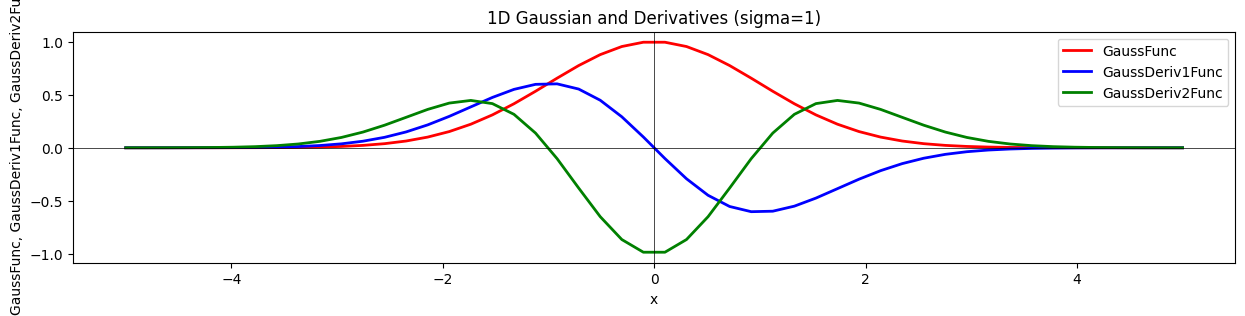

In [ ]:
# Con la siguiente figura verificamos que las funciones Gaussianas implementadas son correctas
plt.figure()
xvalues = np.linspace(-5, 5)
yvalues1 = GaussFunc(xvalues,1)
yvalues2 = GaussDeriv1Func(xvalues,1)
yvalues3 = GaussDeriv2Func(xvalues,1)
plt.plot(xvalues, yvalues1, lw=2, color='red',
label='GaussFunc')
plt.plot(xvalues, yvalues2, lw=2, color='blue',
label='GaussDeriv1Func')
plt.plot(xvalues, yvalues3, lw=2, color='green',
label='GaussDeriv2Func')
plt.title('1D Gaussian and Derivatives (sigma=1)')
plt.xlabel('x')
plt.ylabel('GaussFunc, GaussDeriv1Func, GaussDeriv2Func')
plt.axhline(0, lw=0.5, color='black')
plt.axvline(0, lw=0.5, color='black')
plt.legend();

FIJAMOS PRIMERO EL TAMAÑO DE LA MÁSCARA


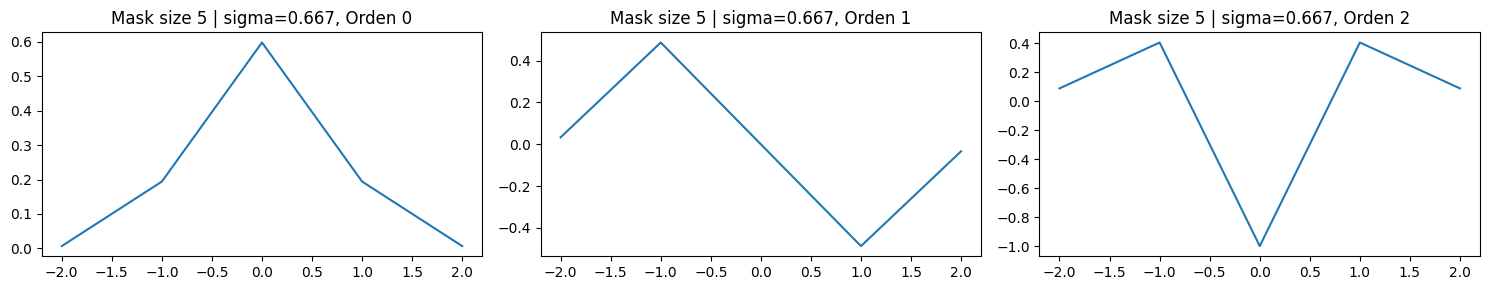

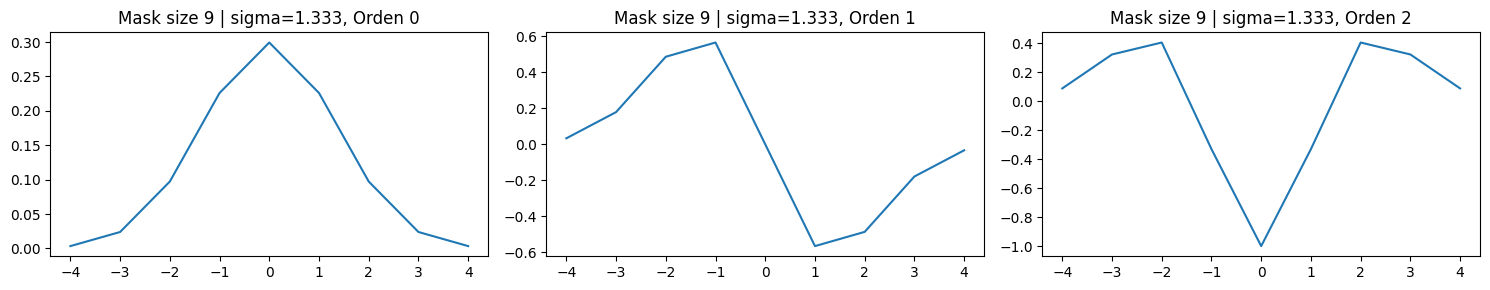

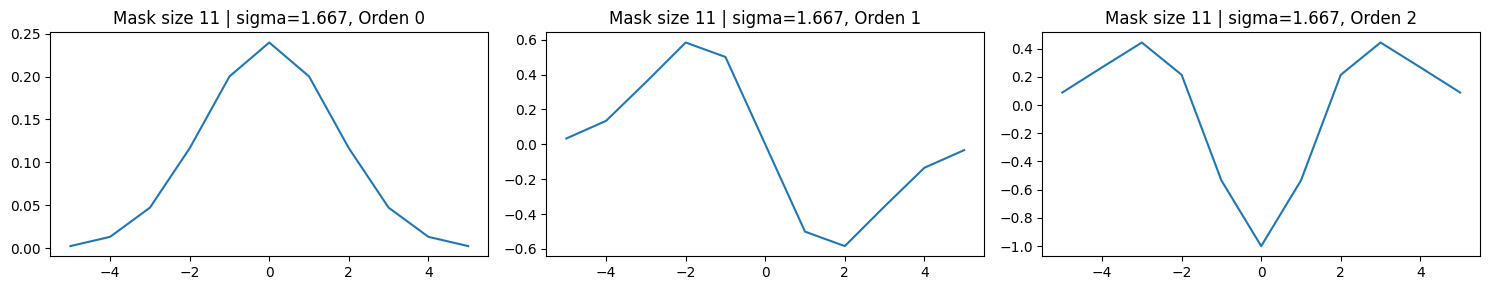

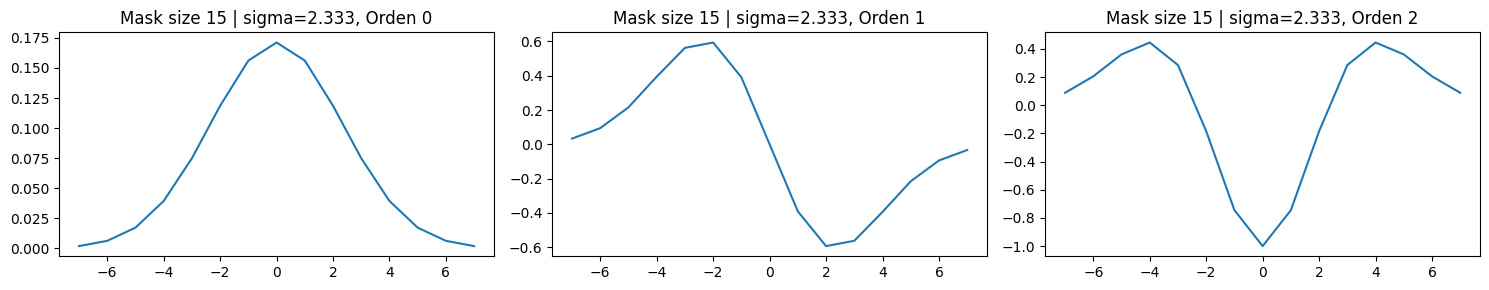

FIJAMOS AHORA EL SIGMA


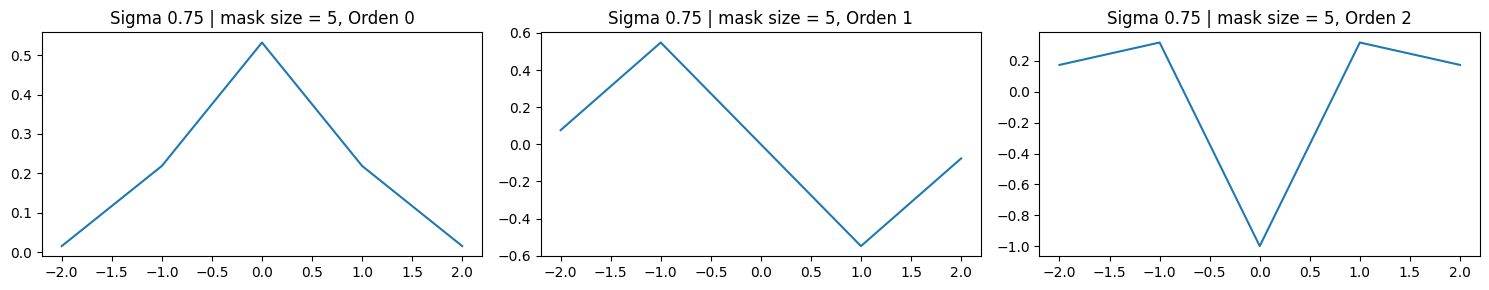

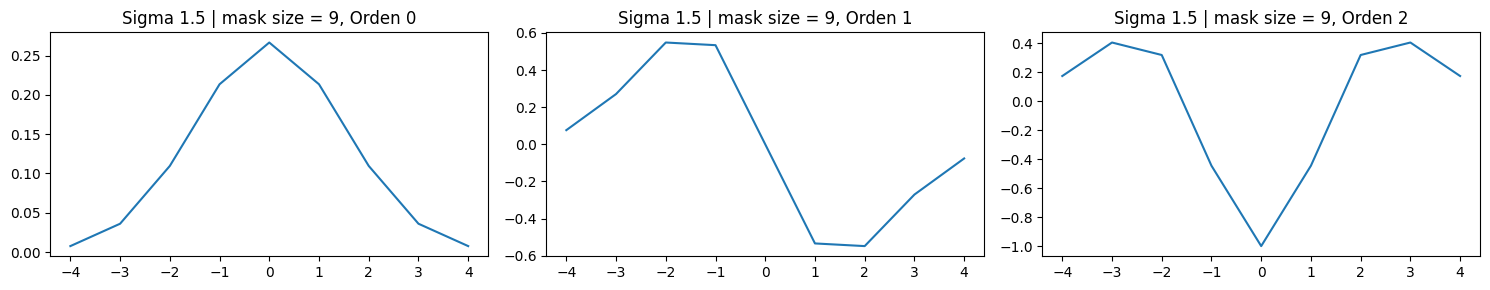

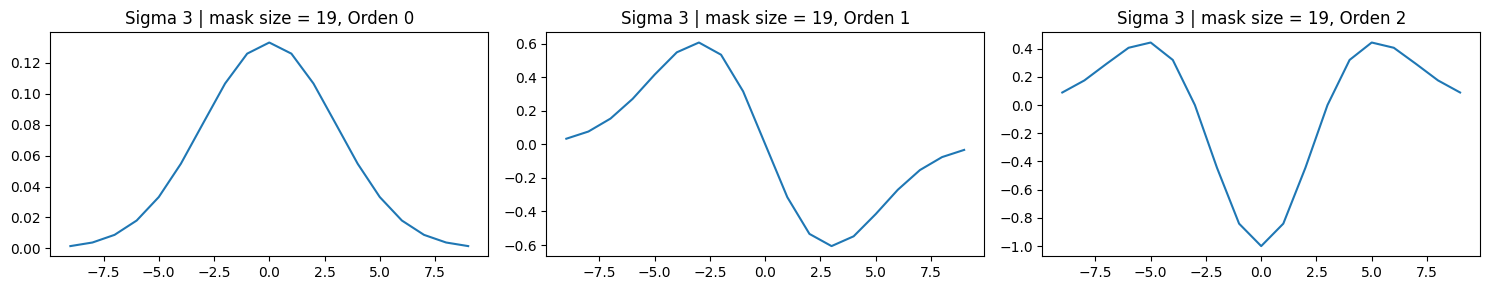

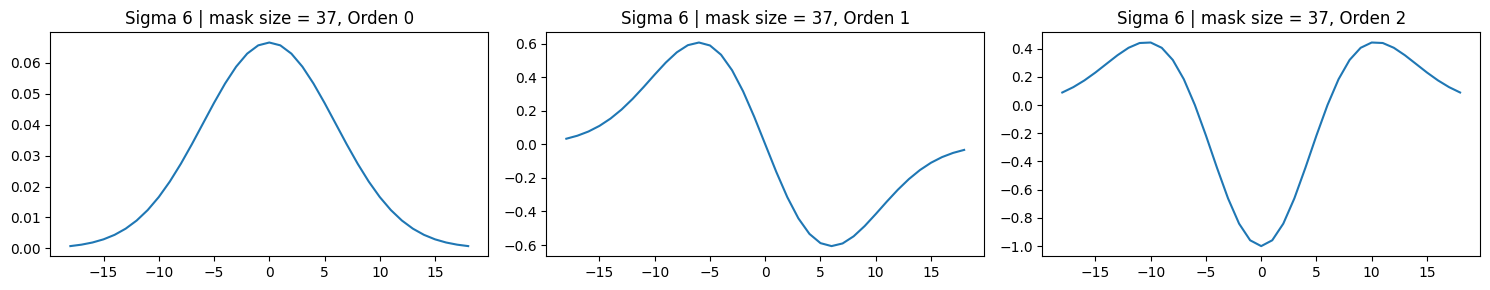

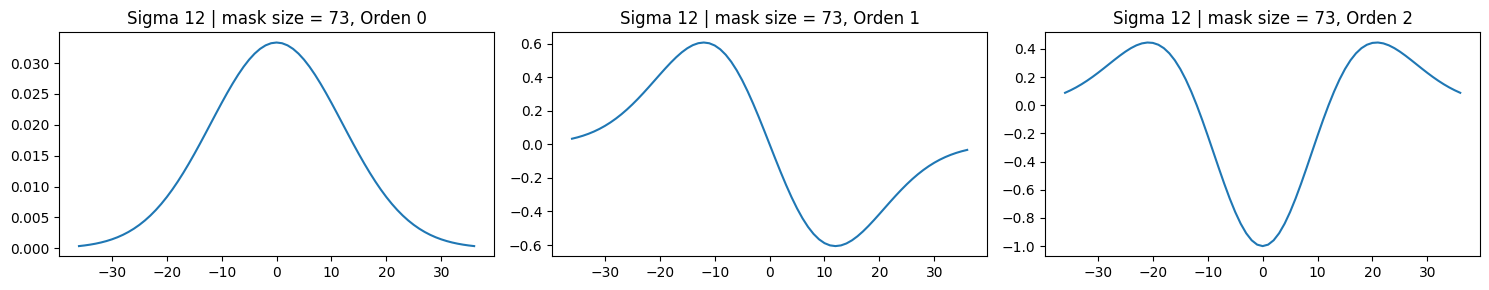

In [ ]:
sigma_values = [0.75,1.5,3,6,12] #A CUBRIR POR EL ALUMNADO
size_masks = [5,9,11,15]#A CUBRIR POR EL ALUMNADO

plt.rcParams["figure.figsize"] = (15, 3)  # para ajustar tamaño del ancho y alto (ejes)

print('FIJAMOS PRIMERO EL TAMAÑO DE LA MÁSCARA')
for sizeMask in size_masks:
    fig, axes = plt.subplots(1, 3, figsize=(15, 3))
    for i in range(3):
        # A CUBRIR POR EL ALUMNADO
        mask = gaussianMask1D(sigma=0, sizeMask=sizeMask, order=i)
        sigma = (sizeMask - 1) / 6
        k = (sizeMask - 1) / 2
        x = np.arange(-k, k + 1, dtype=np.float64)
        axes[i].plot(x, mask)
        axes[i].set_title(f"Mask size {sizeMask} | sigma={sigma:.3f}, Orden {i}")
        axes[i].axis('on')
    plt.tight_layout()
    plt.show()

print('FIJAMOS AHORA EL SIGMA')
for sigma in sigma_values:
    fig, axes = plt.subplots(1, 3, figsize=(15, 3))
    for i in range(3):
        # A CUBRIR POR EL ALUMNADO
        mask = gaussianMask1D(sigma=sigma, sizeMask=0, order=i)
        k = int(math.ceil(3.0 * float(sigma) - 0.5))
        T = 2 * k + 1
        x = np.arange(-k, k + 1, dtype=np.float64)
        axes[i].plot(x, mask)
        axes[i].set_title(f"Sigma {sigma} | mask size = {T}, Orden {i}")
        axes[i].axis('on')
    plt.tight_layout()
    plt.show()

## B) (1.5 puntos)

En este apartado se debe leer una imagen en escala de grises (`'motorcycle.bmp'`) y esta debe ser filtrada mostrando el resultado de la convolución con: a) una Gaussiana, b) la primera derivada de la Gaussiana en $X$, c) la primera derivada de la Gaussian en $Y$, d) la segunda derivada de la Gaussiana en $X$, y e) la segunda derivada de la Gaussiana en $Y$. Para ello, hay que:
1. emplear los siguientes sigmas ($\{0.75,1.5,3,6, 12\}$),
2. usar la función de OpenCV `sepFilter2D()` con las máscaras calculadas a partir de las funciones desarrolladas en el apartado anterior,
3. mostrar todas las imágenes dentro del mismo canvas, tal y como se muestra más abajo,
4. analizar los resultados obtenidos y discutir si se corresponden con lo se esperaría obtener en base a nuestro conocimiento de la teoría.




<font color="blue">Para realizar este apartado primero llevado a cabo la función my2DConv, que simplemente para cada valor con el que vamos a trabajar de los ordenes de la derivada, devuelve la imagen correspondiente.

<font color="blue">Para realizarlo tenemos en cuenta que la Gaussiana 2D es separable, por lo que resulta sencillo calcular sus derivas primera y segunda con respecto a cada una de sus dos variables, haciendo uso de la función gaussianMask1D.

<font color="blue">Esta información está extraida de la documentación de sepFilter2D:
 This function applies a separable linear filter to an image by first filtering each row with the 1D kernel kernelX and then filtering each column of the result with the 1D kernel kernelY.
 In the provided call cv2.sepFilter2D(im, -1, maskG, maskG), the source image is im, the destination image depth is specified as -1 (which means it will be the same as the source image depth), and both the horizontal (kernelX) and vertical (kernelY) kernels are set to maskG.

 <font color="blue">Simplemente debemos de tener en cuenta que para que si el tipo de la imagen de entrada es uint8 no aparazcan solo valores positivos, en vez de ddepth=-1 vamos a usar cv2.CV_64F.

 <font color="blue">Posteriormente leemos la imagen como float para evitar problemas de precisión y truncamiento de valores enteros.

 <font color="blue">Y pasamos a visualizar la imagen aplicando los distintos filtros.

<font color="blue">**Análisis de resultados:**

<font color="blue">*Suavizado Gaussiano (G)*

<font color="blue">Al aumentar σ (de 0.75 → 12) la imagen se vuelve progresivamente más borrosa: se atenúan texturas finas (grano de la tela, radios de la rueda) y se difuminan los bordes.

<font color="blue">Esto se debe a que el parámetro σ es la escala/ancho del kernel Gaussiano, y controla la cantidad de suavizado.

<font color="blue">La media (brillo global) se conserva porque el kernel está normalizado a suma 1.

<font color="blue">*1ª derivada de Gauss en Y (Gy) y en X (Gx)*

<font color="blue">Gy realza cambios a lo largo del eje y → bordes “horizontales” en la imagen. Las arrugas horizontales del telón y los cambios verticales de iluminación aparecen muy marcados.

<font color="blue">Gx realza cambios a lo largo de x → bordes “verticales” (montantes de la moto, neumático, cantos del depósito).

<font color="blue">En las ruedas al ser circulares se puede ver que tiene un efecto "opuesto".

<font color="blue">*2ª derivada de Gauss en Y (Gyy) y en X (Gxx)*

<font color="blue">Simetría par: borde → lóbulo central de un signo y dos lóbulos laterales del contrario.

<font color="blue">Zeros–crossing: el cruce por cero tiende a alinearse con el centro del borde suavizado; por eso los contornos “limpios” se ven mejor si miras dónde cambia el signo, es decir, que resulta más sencillo localizar los bordes como hemos visto en teoría.

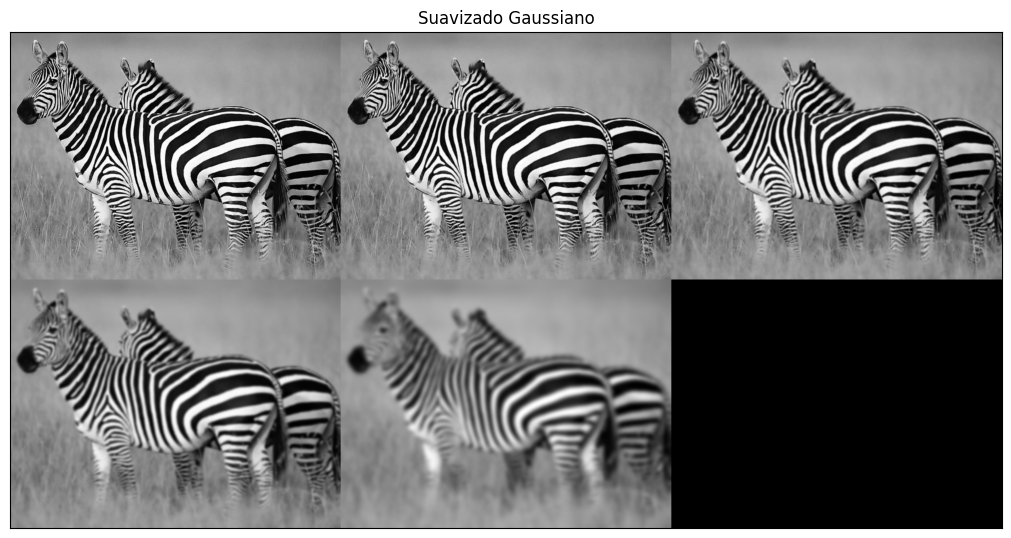

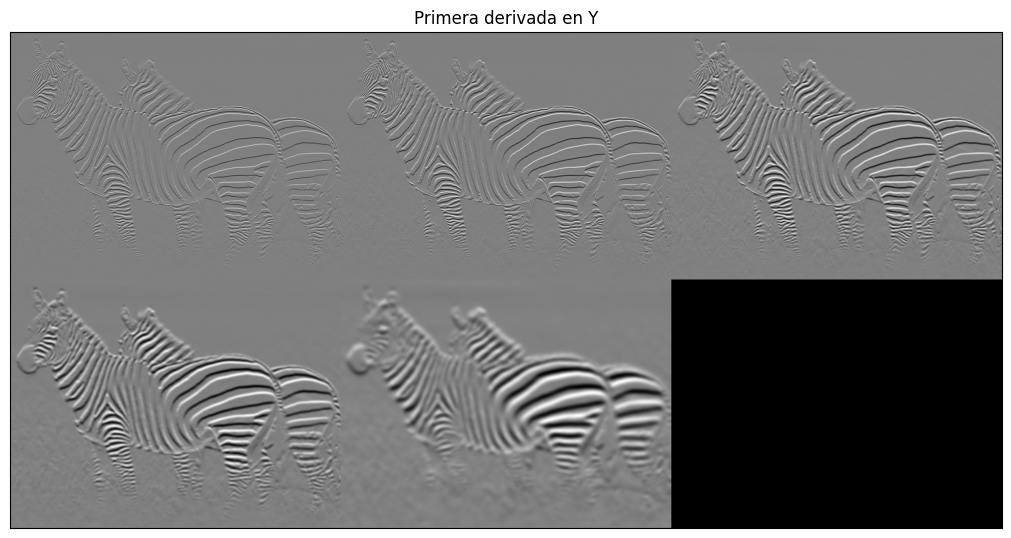

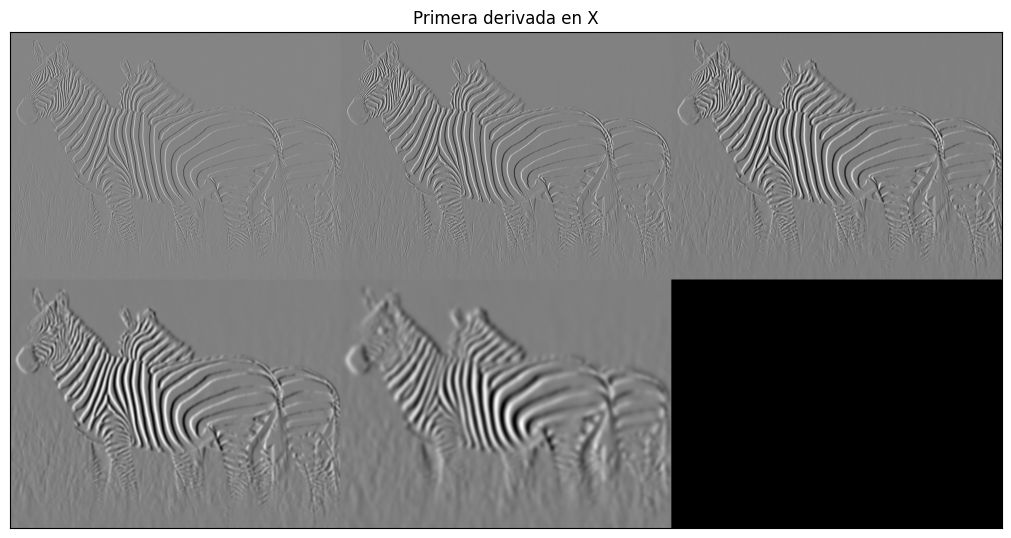

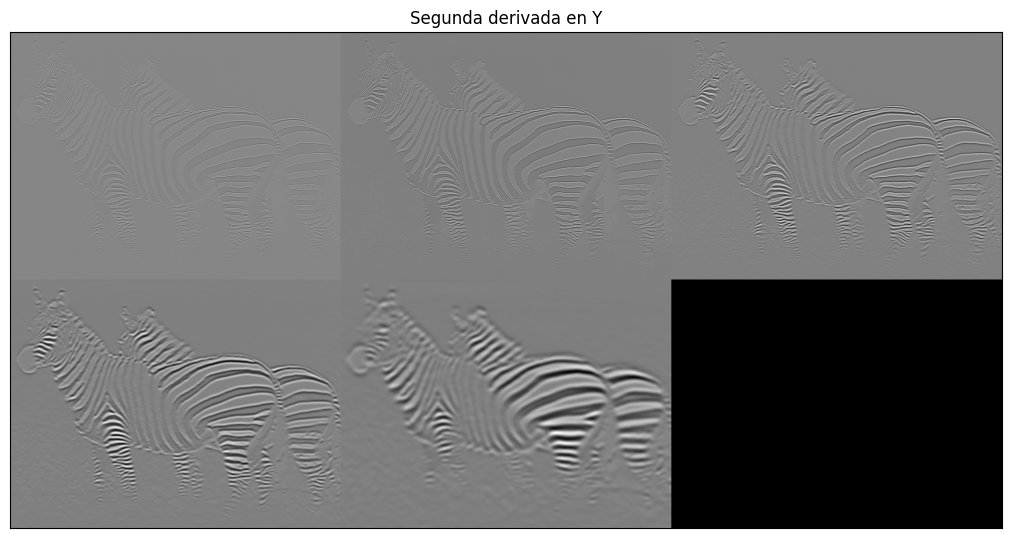

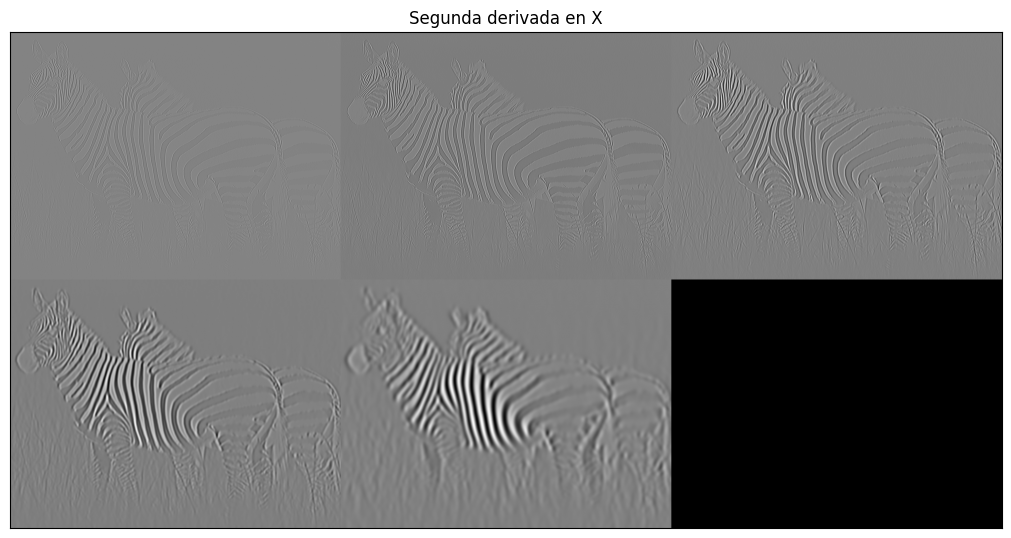

In [ ]:
def my2DConv(im, sigma, orders):
  #A CUBRIR POR EL ALUMNADO
  maskG = gaussianMask1D(sigma=sigma, sizeMask=0, order=0)
  maskGx = gaussianMask1D(sigma=sigma, sizeMask=0, order=1)
  maskGxx = gaussianMask1D(sigma=sigma, sizeMask=0, order=2)
  if orders==[0,0]: # Suavizado Gaussiano
    return cv2.sepFilter2D(im,cv2.CV_64F,maskG,maskG) #A CUBRIR POR EL ALUMNADO
  elif orders==[1,0]: #A CUBRIR POR EL ALUMNADO
    return cv2.sepFilter2D(im,cv2.CV_64F,maskGx,maskG)
  elif orders==[0,1]: #A CUBRIR POR EL ALUMNADO
    return cv2.sepFilter2D(im,cv2.CV_64F,maskG,maskGx)
  elif orders==[2,0]: #A CUBRIR POR EL ALUMNADO
    return cv2.sepFilter2D(im,cv2.CV_64F,maskGxx,maskG)
  elif orders==[0,2]: #A CUBRIR POR EL ALUMNADO
    return cv2.sepFilter2D(im,cv2.CV_64F,maskG,maskGxx)
  else:
    print('Error en el orden de la derivada')

sigmas = [0.75,1.5,3,6,12] #A CUBRIR POR EL ALUMNADO


im=cv2.imread(get_image('motorcycle.jpg'),0).astype(np.float64)

vim0=[]
orders=[0,0]
for sigma in sigmas:
  vim0.append(rangeDisplay01(my2DConv(im,sigma,orders),True))

#A CUBRIR POR EL ALUMNADO
displayMI_ES(vim0,'Suavizado Gaussiano',2)

#A CUBRIR POR EL ALUMNADO
vim1=[]
orders=[0,1]
for sigma in sigmas:
  vim1.append(rangeDisplay01(my2DConv(im,sigma,orders),True))

#A CUBRIR POR EL ALUMNADO
displayMI_ES(vim1,'Primera derivada en Y',2)

vim2=[]
orders=[1,0]
for sigma in sigmas:
  vim2.append(rangeDisplay01(my2DConv(im,sigma,orders),True))

#A CUBRIR POR EL ALUMNADO
displayMI_ES(vim2,'Primera derivada en X',2)

vim3=[]
orders=[0,2]
for sigma in sigmas:
  vim3.append(rangeDisplay01(my2DConv(im,sigma,orders),True))

#A CUBRIR POR EL ALUMNADO
displayMI_ES(vim3,'Segunda derivada en Y',2)

vim4=[]
orders=[2,0]
for sigma in sigmas:
  vim4.append(rangeDisplay01(my2DConv(im,sigma,orders),True))

#A CUBRIR POR EL ALUMNADO
displayMI_ES(vim4,'Segunda derivada en X',2)


## C) (1 punto)

En este apartado hay que emplear la función `my2DConv()`, creada en el apartado anterior (y que, a su vez, emplea la función de OpenCV `sepFilter2D()`) con $\sigma=1.0$ para calcular y mostrar el gradiente (2 imágenes: magnitud y orientación) y la Laplaciana de la Gaussiana. Se debe explicar el trabajo realizado, incluyendo las expresiones matemáticas subyacentes y el análisis, al igual que en todos los ejercicios, relativo a si los resultados obtenidos se corresponden con lo esperado. Se emplea la misma imagen del apartado anterior: `motorcycle.bmp`

 <font color="blue">Vamos a empezar a explicar el gradiente de una imagen, que mide cómo cambia la intensidad de los píxeles de la misma, es decir, la dirección y magnitud del cambio más fuerte en los valores de brillo.

 <font color="blue">El gradiente indica dónde y cómo cambia más rápidamente la intensidad de los píxeles, lo que equivale a detectar bordes o contornos.

 <font color="blue">Matemáticamente, dada una imagen suavizada I,

 <font color="blue">\begin{equation}
I(x,y;\sigma) = \bigl(G(\cdot,\cdot;\sigma) * f\bigr)(x,y)
\end{equation}

 <font color="blue">es el vector formado por:

 <font color="blue">\begin{equation}
I_x = \frac{\partial I}{\partial x} = G_x(\sigma) * f, \qquad
I_y = \frac{\partial I}{\partial y} = G_y(\sigma) * f
\end{equation}

 <font color="blue">de donde la magitud y la dirección se calculan de la siguiente manera:

 <font color="blue">\begin{equation}
|\nabla I| = \sqrt{I_x^2 + I_y^2,}, \qquad
\theta = \operatorname{atan2}(I_y,I_x)
\end{equation}

 <font color="blue">Por otro lado, recordar que un kernel es separable si y solo si todas sus columnas/filas son linealmente dependientes, es decir, el rango de la matriz(el máximo número de columnas/filas linealmente independientes) es 1.

 <font color="blue">Resulta que tanto la Gaussiana como sus derivadas son separables, lo que permite reducir el coste computacional considerablemente.

 <font color="blue">Ahora si vamos con el operador Laplaciano, que no es más que la divergencia del gradiente,

 <font color="blue">\begin{equation}
\nabla^2 I = I_{xx} + I_{yy}
\end{equation}

 <font color="blue">En el caso de la Laplaciana de la Gaussiana, tenemos que

 <font color="blue">\begin{equation}
I(x,y;\sigma) = \bigl(G(\cdot,\cdot;\sigma) * f\bigr)(x,y)
\end{equation}

 <font color="blue">por lo que nos queda

 <font color="blue">\begin{equation}
\nabla^2 I = (I*G)_{xx} + (I*G)_{yy} = I*(G_{xx} + G_{yy}) = I*G_{xx} + I*G_{yy}
\end{equation}

 <font color="blue">De donde usando la separabilidad de la Gaussiana nos queda

 <font color="blue">\begin{equation}
L = \sigma^2*(G_{xx} + G_{yy})
\end{equation}

 <font color="blue">Multiplicamos por sigma al cuadrado para normalizar la segunda derivada, aunque en el ejercicio nos dicen que sigma = 1, por lo que no va a afectar.

 <font color="blue">**Análisis de resultados**

 <font color="blue">*Magnitud del gradiente (‖∇L‖)*= La magnitud sale grande donde la imagen cambia mucho en poco espacio (un borde).
Podemos comprobar en la imagen que se resaltan los bordes de la moto.

 <font color="blue">Si usamos σ = 1, antes de calcular el gradiente hemos suavizado un poco la imagen, así que quitamos ruido fino y los bordes salen más limpios que con σ muy pequeño.

 <font color="blue">*Orientación (θ)* = La orientación dice la dirección del crecimiento máximo (la “flecha” del gradiente). Imaginemos que pasa del negro(pixel = 0) a blanco(pixel = 255), luego el gradiente sube, al pasar de negro a blanco, como su dirección sigue la direccción del crecimiento máximo, va a apuntar hacia arriba. Por ejemplo cuando en la imagen vemos que algunas partes del telón están todo a negro, es porque no hay cambio de dirección, en la imagen original podemos comprobar que efectivamente esa zona tiene el mismo color.

 <font color="blue">También comentar que cuando el cambio es muy pequeño (‖∇L‖ bajo), esa dirección puede ser poco fiable

 <font color="blue">*Laplaciana de Gauss (LoG)* =
La LoG combina las segundas derivadas en X e Y. Alrededor de un borde genera un lóbulo positivo y otro negativo, y cruza por cero justo en el centro del borde. Esto facilita la detección de bordes
Si cambias la escala (σ), las respuestas cambian de tamaño. Multiplicar por σ² (normalización por escala) compensa ese efecto para poder comparar amplitudes entre distintas σ.

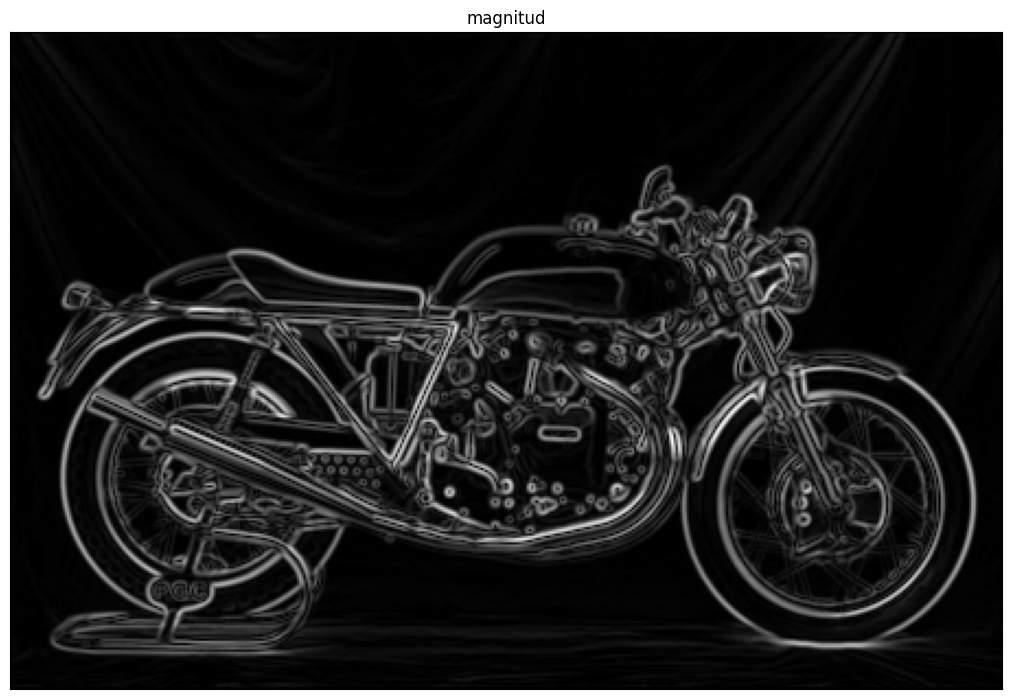

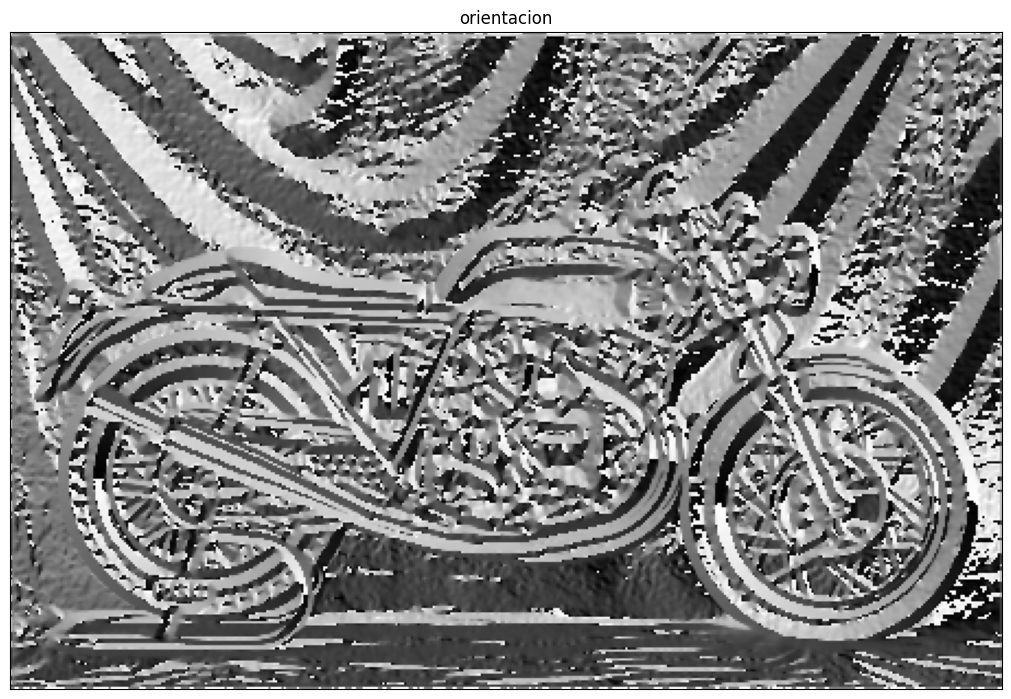

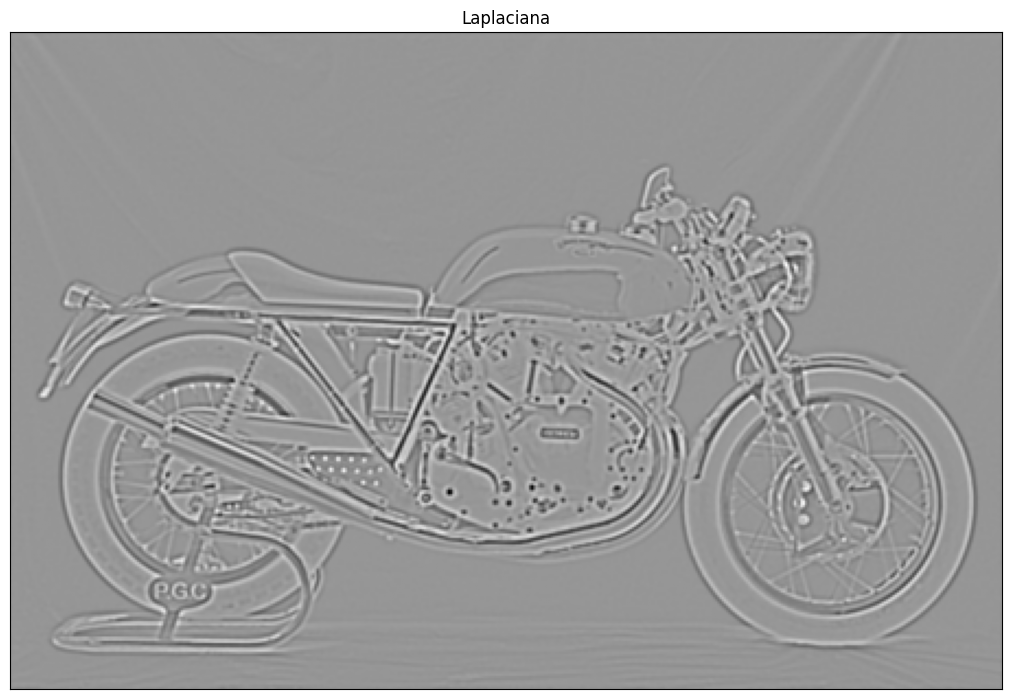

In [ ]:
#Dudas: explicacion?

def gradientIM(im,sigma):
  #A CUBRIR POR EL ALUMNADO
  dx = my2DConv(im, sigma, [1, 0])
  dy = my2DConv(im, sigma, [0, 1])
  return dx,dy

def laplacianG(im,sigma):
  dxx = my2DConv(im, sigma, [2, 0])
  dyy = my2DConv(im, sigma, [0, 2])
  log = dxx + dyy
  return log #A CUBRIR POR EL ALUMNADO



#A CUBRIR POR EL ALUMNADO
sigma = 1.0
im=cv2.imread(get_image('motorcycle.bmp'),0).astype(np.float64)

# Gradiente
dx, dy = gradientIM(im, sigma)
mag = np.sqrt(dx*dx + dy*dy)            # magnitud
ori = np.arctan2(dy, dx)                # orientación en radianes (-pi, pi]

# Rango para mostrar:
mag_disp = rangeDisplay01(mag, True)
# mapea orientación a [0,1] (0..pi)
ori_01 = ( (ori + np.pi) / (2*np.pi) )  # [-pi,pi] -> [0,1]

displayIm(rangeDisplay01(mag, True), 'magnitud', 2)
displayIm(rangeDisplay01(ori_01, True), 'orientacion', 2)

# Laplaciana de Gauss
log = laplacianG(im, sigma)
displayIm(rangeDisplay01(log, True), 'Laplaciana', 2)

## D) (1.5 puntos)  

Implemente una función para realizar "a mano" la convolución separable (es decir, empleando kernels 1D). Dicha función debe recibir como entrada una imagen (con el _padding_ adecuado, en caso de que lo necesite, ya incorporado) y un kernel 1D, y debe proporcionar como salida la imagen convolucionada con el kernel en ambas direcciones. Es decir, el hecho de introducir, o no, padding es un elemento externo a la función de convolución que lo único que hace es realizar la convolución separable encajando el kernel hasta el límite de la imagen de entrada.

Una vez haya implementado la función, aplique un kernel de derivadas en $X$ a la imagen `zebra.jpg` (usando los kernels de tamaño $5$, generados por nuestras funciones del Ejercicio $1$, y dejando que sea la propia función de creación del kernel la que determine el $\sigma$ adecuado), y compare el resultado con el de `cv2.Sobel` (en donde se debe optar por la misma estrategia: fijando $ksize=5$ y dejando que sea la propia función de OpenCV la que escoja el sigma). ¿Hay diferencias (sea a nivel de resultado final o de tiempo de ejecución)? En caso afirmativo, ¿a qué se pueden deber?

**Nota**: el código del alumnado no puede ser más de $50$ veces más lento que el de OpenCV. Ese es el límite superior aceptable. Se debe optimizar la ejecución para, al menos, estar en ese orden de magnitud comparativamente con el rendimiento ofrecido por OpenCV. Estos tiempos de ejecución se deben medir usando:

```python
starttime = time.perf_counter()
# CÓDIGOS DE CONVOLUCIÓN
duration = timedelta(seconds=time.perf_counter() - starttime)
```


<font color="blue">En este ejercicio hay que calcular la convolución separable, para ello hay que aplicar la convolución 1D por filas y por columnas. Para hacerlo más eficiente vamos a hacer lo siguiente:

<font color="blue">Dado un kernel $k$ 1D de tamaño $w$ con centro $r = ⌊w/2⌋$.
Para una pasada vertical 1D, la salida en el píxel
$(x,y)$ es:

<font color="blue">\begin{equation}
out(x,y) = \sum_{i=0}^{w-1} k[i]im\bigl(x + (i-r), y\bigr).
\end{equation}

<font color="blue">Por lo que realmente lo que tenemos que hacer es quedarnos con la imagen pero sumandole o restandole $(i-r)$. Es decir, cogemos cada valor del kernel $k[i]$ y lo multiplicamos por todos los valores de la imagen correspondientes. En el caso del valor central del kernel por ejemplo, (cuando i-r=0) out(x,y) es la imagen de entrada con cada pixel multiplicado por $k[i]$. Además al haber padding de ceros alrededor, no afecta a los bordes.

<font color="blue">src = el bloque válido de entrada que no se sale con ese desplazamiento,

<font color="blue">dst = el bloque alineado de salida donde debe acumularse,

<font color="blue">y hacemos
\begin{equation}
dst \mathrel{+}= k[i]\cdot\text{src}.
\end{equation}

<font color="blue">Para ellos usamos las funciones add y multiply de numpy.

<font color="blue">Por útimo almacenamos ese valor en la imagen de salida.

<font color="blue">**Análisis de resultados**

<font color="blue">Según he leído Sobel es una herramienta fundamental para detectar bordes y lo hace calculando el gradiente de una imagen y detectando cambios rápidos de intensidad tanto en dirección vertical como horizontal.

<font color="blue">Comparando las dos imágenes, ambas son prácticamente iguales. Se puede apreciar que usando Sobel los bordes se aprecian un poco más, se puede notar mejor en el estómago de la zebra.

<font color="blue">Luego esto se puede deber a que Sobel detecta ligeramente mejor los bordes, esto se puede ver también al calcular la diferencia(en valor absoluto) de ambas imágenes(a mayor diferencia, más blanco). Además Sobel usa un padding distinto(BORDER_DEFAULT) lo que puede hacer que haya diferencias en los bordes exteriores de la imagen.

<font color="blue">Respecto al tiempo, vemos que Sobel es más rápido, aunque entra dentro del rango requerido en el ejercicio

In [ ]:
def convolve1D(image,kernel):
    #A CUBRIR POR EL ALUMNADO
    rows = image.shape[0]
    columns = image.shape[1]
    w = kernel.size

    r = w // 2
    rows, cols = image.shape[:2]
    out = np.zeros((rows, cols), dtype=np.float64)

    for i, ki in enumerate(kernel):
        shift = i - r
        if shift >= 0: #on the right side of the kernel and the center
            # from row 0 included until row (rows-shift) excluded and all columns
            src = image[:rows-shift, :]
            #from row shift until the end and all columns
            dst = out[shift:, :]
        else: #on the left side of the kernel
            s   = -shift
            src = image[s:, :]
            dst = out[:rows-s, :]
        np.add(dst, np.multiply(src, ki, dtype=src.dtype), out=dst)

    return out

def convolve2D(image, kx, ky):
    #A CUBRIR POR EL ALUMNADO
    output = convolve1D(image, ky)
    kx.reshape(-1,1)
    image_traspuesta = np.transpose(output)
    output2 = np.transpose(convolve1D(image_traspuesta, kx))


    return output2 #A CUBRIR POR EL ALUMNADO

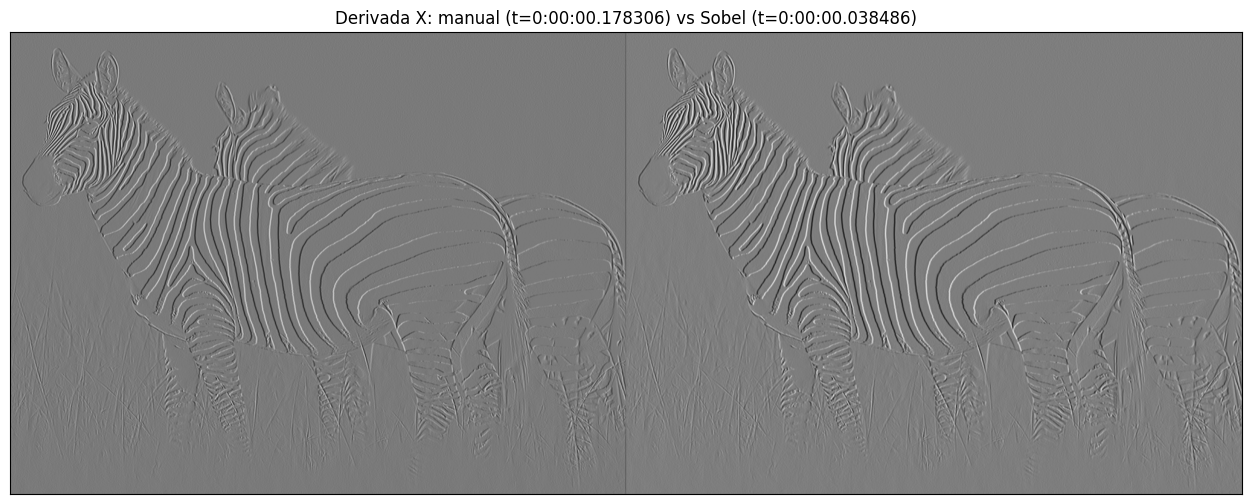

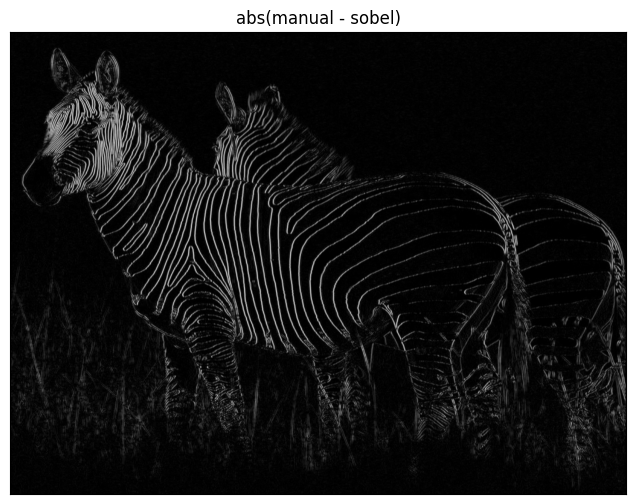

In [ ]:
import time
from datetime import timedelta

zebra = readIm(get_image('zebra.jpg'), 0).astype(np.float64)

sizeMask = 5
kx = gaussianMask1D(sigma=0, sizeMask=sizeMask, order=1)  # derivada en X
ky = gaussianMask1D(sigma=0, sizeMask=sizeMask, order=0)  # suavizado en Y

starttime = time.perf_counter()
gx_manual = convolve2D(zebra, kx, ky)
duration = timedelta(seconds=time.perf_counter() - starttime)

starttime = time.perf_counter()
#parámetros: imagen, tipo de datos, orden de la derivada en x y en y y tamaño del kernel
#con dx=1 y dy=0 calculamos el gradiente horizontal
gx_sobel = cv2.Sobel(zebra, cv2.CV_64F, 1, 0, ksize=5)
duration_sobel = timedelta(seconds=time.perf_counter() - starttime)

# 5) Visualización y normalización para ver bien
displayMI_ES(
    [rangeDisplay01(gx_manual, True), rangeDisplay01(gx_sobel, True)],
    title=f'Derivada X: manual (t={duration}) vs Sobel (t={duration_sobel})',
    factor=2
)

# 6) Medida de diferencia (puramente orientativa, por distintas definiciones de kernel)
diff = gx_manual - gx_sobel
displayIm(rangeDisplay01(np.abs(diff), True), 'abs(manual - sobel)', 2)


# **Ejercicio 2**:  Pirámides Gaussianas y Laplacianas (4.5 puntos)







## A) (1 punto)

Construya una pirámide Gaussiana de $5$ niveles empleando máscaras Gaussianas de tamaño $5\times5$. No se permite emplear las funciones `pyrUp()` y `pyrDown()` de OpenCV. `cv2.resize()` no se puede emplear a la hora de crear la pirámide Gaussiana (apartado A), pero sí a la hora de crear la pirámide Laplaciana (apartado B) y cuando se reconstruye la imagen original a partir de esta última pirámide (apartado C). En todos los apartados de este ejercicio se debe emplear la imagen `einstein.bmp`.

<font color="blue">Para construir la pirámide Gaussiana tenemos que seguir los siguiente pasos:

1) suavizar
2) Subsamplear

<font color="blue">Y repetir el número de pisos que queramos que tenga la pirámide. Para suavizar hemos usado la función convolve2D implementada en el ejercicio 1.d y posteriormente nos quedamos con las posiciones pares en las filas y las columnas, quedandonos con una imagen con la mitad de tamaño como resultado.

In [ ]:
'''
This function displays a pyramid of images, providing as input the list of images to display.

Example of use:
im1=readIm(get_image('apple.jpg'),1)
images = [im1, cv2.resize(im1,(im1.shape[0]//2,im1.shape[1]//2),cv2.INTER_LINEAR), cv2.resize(im1,(im1.shape[0]//4,im1.shape[1]//4),cv2.INTER_LINEAR), cv2.resize(im1,(im1.shape[0]//8,im1.shape[1]//8),cv2.INTER_LINEAR), cv2.resize(im1,(im1.shape[0]//16,im1.shape[1]//16),cv2.INTER_LINEAR)]

displayPyramid(images, title='Piramide de Manzanas')

'''
def displayPyramid(vim, title='result'):
  temp = np.zeros_like(vim[0])
  if np.mod(temp.shape[1],2)==0:
    h = temp[:, :temp.shape[1]//2]
  else:
    h = temp[:, :(temp.shape[1]//2)+1]
  out = np.hstack((temp, h))
  top = 0
  out[0:vim[0].shape[0], 0:vim[0].shape[1]] = vim[0]
  left = vim[0].shape[1]
  for i in range(1, len(vim)):
    out[top:top+vim[i].shape[0], left:left + vim[i].shape[1]] = vim[i]
    top += vim[i].shape[0]
  displayIm(out, title)

<font color="blue">Para el ejercicio 3, cuando se pide hibridar imágenes a color, la función convolve2D solo se aplica a un canal(balnco y negro hasta ahora), por lo que tenemos que generalizar esta función para que permita recibir imágenes a color.

<font color="blue">Con esta función seleccionamos cada uno de los canales de la imagen y aplicamos el filtro separable a cada uno de ellos, con lo que en chans se guardan 3 imágenes que volvemos a unir con np.stack.

In [ ]:
def convolve2D_any(image, kx, ky):
    if image.ndim == 2:
        return convolve2D(image, kx, ky)
    chans = [convolve2D(image[..., c], kx, ky) for c in range(image.shape[2])]
    return np.stack(chans, axis=2)

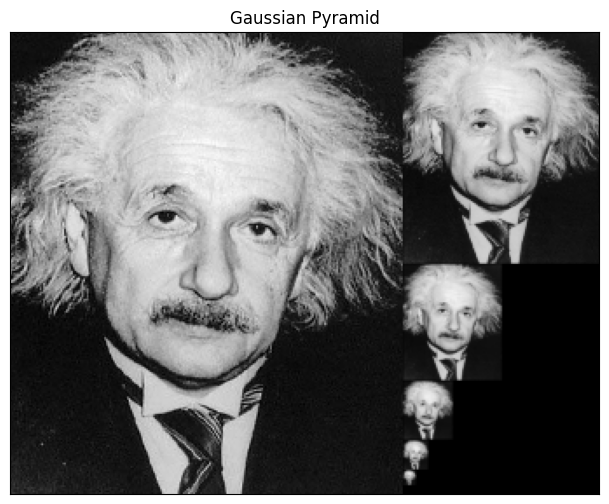

In [ ]:
def pyramidGauss(im,sizeMask=7, nlevel=4):
  #A CUBRIR POR EL ALUMNADO
  maskG = gaussianMask1D(sigma=0, sizeMask=sizeMask, order=0)
  out = [im]
  for i in range(nlevel):
    # Suavizado Gaussiano
    im = convolve2D_any(out[-1], maskG, maskG)
    #subsumple
    im_copia = im[::2, ::2]
    out.append(im_copia)

  return out#A CUBRIR POR EL ALUMNADO

im=cv2.imread(get_image('einstein.bmp'),0).astype(np.float64)
pyrG = pyramidGauss(im,sizeMask=5, nlevel=5)
displayPyramid(pyrG,'Gaussian Pyramid')


## B) (1 punto)

Use su código del apartado anterior para implementar una función que permita construir una pirámide Laplaciana de $5$ niveles.

<font color="blue"> Para construir la pirámide Laplaciana tenemos que seguir el siguiente proceso:

1) Partimos de la pirámide Gaussiana
2) Para obtener cada elemento de la pirámide Laplaciana hacemos lo siguiente(partiendo desde la base de la gaussiana(la imagen más grande)): le restamos a cada imagen la expansión de la que está justo encima, teniendo en cuenta que la cima de ambas pirámides coincide.

<font color="blue">Para expandir las imágenes usamos el método cv2.resize(), que es una función de OpenCV que se usa para escalar imágenes especificando el tamaño de la salida(dsize) o el factor de escalado(fx y fy).
La función admite varios métodos de interpolación, como cv2.INTER_LINEAR(por defecto, interpolación bilinear), cv2.INTER_AREA (ideal para reducir imágenes), cv2.INTER_CUBIC (interpolación bicúbica), y cv2.INTER_NEAREST (interpolación del vecino más cercano), que afecta a la calidad de la imagen escalada.


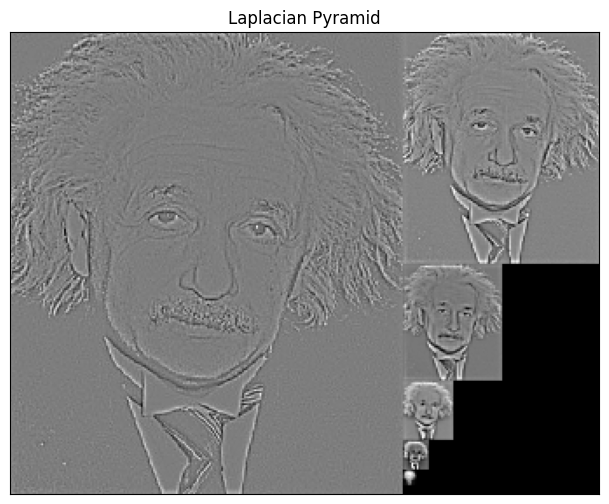

In [ ]:
def pyramidLap(im, sizeMask,nlevel=4,flagInterp=cv2.INTER_LINEAR  ):
  #A CUBRIR POR EL ALUMNADO
  G = pyramidGauss(im, sizeMask=sizeMask, nlevel=nlevel)

  L = []
  L_visual = []
  for i in range(len(G) - 1):
      Gi   = G[i]
      Gi1  = G[i + 1]
      H, W = Gi.shape[:2]
      up = cv2.resize(Gi1, (W, H), interpolation=flagInterp)
      L.append(Gi - up)
      L_visual.append(rangeDisplay01(Gi - up))

  L.append(G[-1])
  L_visual.append(rangeDisplay01(G[-1]))
  return L, L_visual

#A CUBRIR POR EL ALUMNADO
pyrL, pyrLvisual = pyramidLap(im,sizeMask=5, nlevel=5)
displayPyramid(pyrLvisual,'Laplacian Pyramid')

## C) (1 punto)

Implemente ahora una función para reconstruir la imagen codificada en la pirámide Laplaciana del apartado 2.B. Verifique que es posible obtener una copia exacta de la imagen original. Para ello, calcule el error de reconstrucción como el _Root Mean Squared Error_ (RMSE) entre los niveles de intensidad de la imagen original y la imagen reconstruida.

<font color="blue">El método para reconstruir la imagen original es simplemente aritmética básica. La pirámide Laplaciana la hemos construido como $L_i = G_i - G_{i+1}$ luego cada elemento $G_i = L_i + G_{i+1}$, y en particular $G_0 = L_0 + G_1$, por lo que partiendo del tope de la pirámide Laplaciana, expandimos esa imagen($G_{i+1}$) y se la sumamos al nivel anterior de la Laplaciana($L_i$) y obtenemos $G_i$. Para obtener la siguiente reconstrucción, sumamos el nivel inferior a $L_i$ con la expansión de $G_i$, y así sucesivamente.

<font color="blue">Siguiendo este procedimiento y usando el mismo método de interpolación para construir la Laplaciana y reconstruir la imagen original, como nos muestra RMSE se reconstruye perfectamente, es decir, no se pierde nada de información.

Error per pixel 0.0


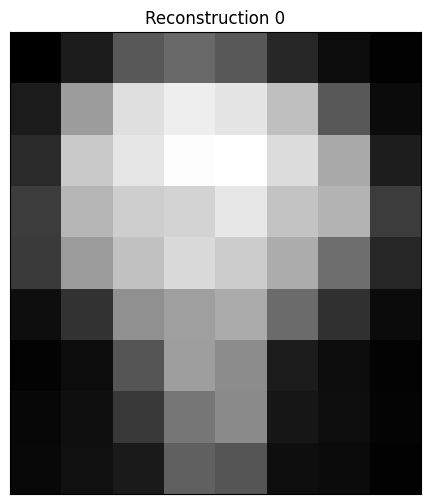

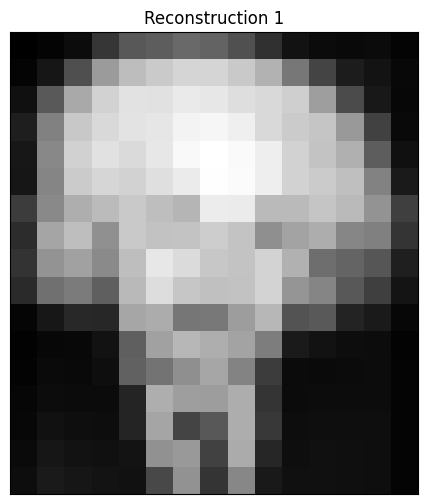

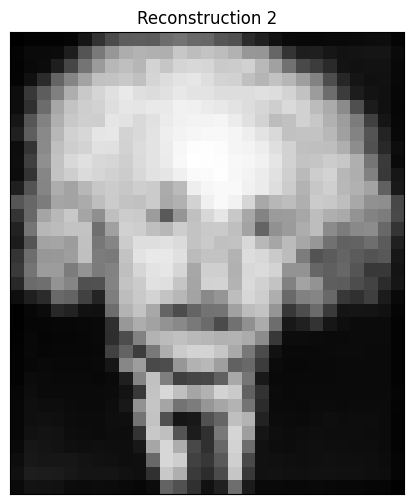

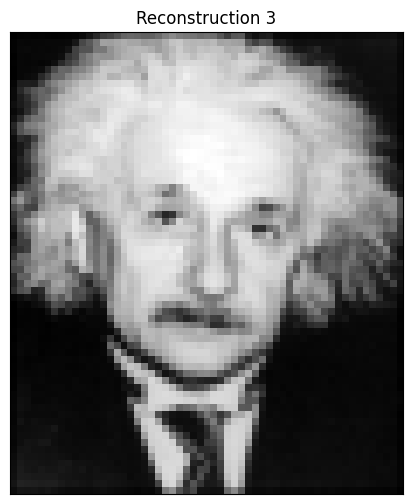

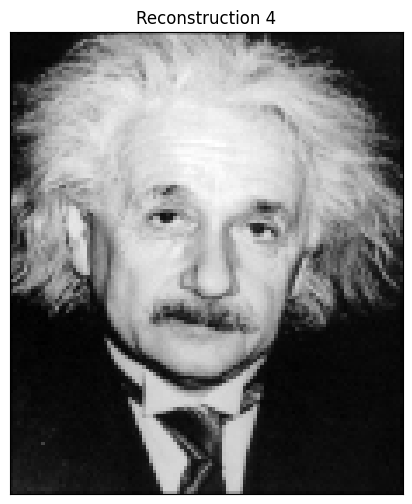

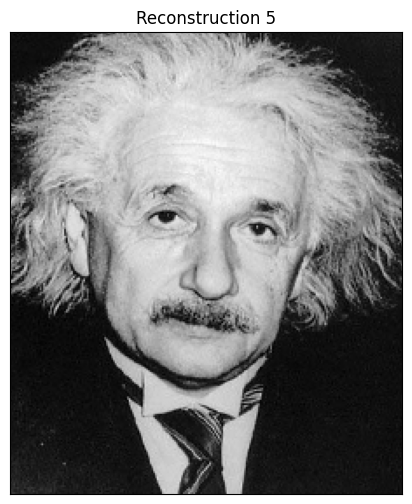

In [ ]:
def reconstructLap(pyL,flagInterp):
  #A CUBRIR POR EL ALUMNADO
  rec = []
  cur = pyL[-1].astype(np.float64)
  rec.append(cur)

  for i in range(len(pyL) - 2, -1, -1):
      target = pyL[i]
      H, W = target.shape[:2]
      cur = cv2.resize(cur, (W, H), interpolation=flagInterp) + target
      rec.append(cur)

  return rec#A CUBRIR POR EL ALUMNADO

#A CUBRIR POR EL ALUMNADO
rec = reconstructLap(pyrL, cv2.INTER_LINEAR)
final = rec[-1]
print('Error per pixel',np.sqrt(np.mean((im - np.round(final)) ** 2)))
for i in range(len(rec)):
  displayIm(rec[i], f"Reconstruction {i}")

## D) (1.5 puntos)

### APARTADO 1 (0.5 puntos)

Imaginemos que tenemos una implementación en donde, a la hora de construir la pirámide Laplaciana, cada nivel lo introducimos normalizado, es decir, empleamos `rangeDisplay01()` antes de introducir el nivel generado en el listado de imágenes que conforman la pirámide Laplaciana. ¿Qué influencia puede tener a la hora de reconstruir la imagen original? ¿Considera que sería una práctica adecuada?

<font color="blue">Al calcular la laplaciana, a cada imagen de la piramide gaussiana le restamos la expansión de la imagen que está encima suya, por lo que puede tomar valores negativos, además sabemos que la Laplaciana representa derivadas, que pueden tomar valores negativos, por lo que al crear la imagen final con displayPyramid formada por la pirámide laplaciana al completo, por defecto se toma el valor más negativo como 0(negro) y el más positivo como 1(blanco) y los demás se escalan, resultando en una escala de grises.

<font color="blue">En cambio si a cada imagen le aplicamos rangeDisplay01() por separado, se aplica esta normalización una a una, pudiendo resultar en que la imagen mantenga el fondo negro.

<font color="blue">Sin embargo, estamos modificando el valor de los pixeles, luego cuando queramos recuperar la imagen original como hacemos en el apartado c), no va a ser posible porque la suma va a dar un valor distinto.

<font color="blue">En conclusión, si lo que queremos es visualizar la pirámide Laplaciana, podemos usar rangeDisplay01() sobre cada imagen de manera individual, por el contrario, si nuestro objetivo es luego recuperar la imagen original, debemos evitarlo.

### APARTADO 2 (0.5 puntos)

Imaginemos ahora que no expandimos de la misma forma al crear la pirámide Laplaciana y al reconstruir la imagen original. En el primer caso, usamos `cv2.resize()`, con `cv2.INTER_LINEAR`, mientras que en el segundo usamos `cv2.pyrUp()`. ¿Esto afecta a la reconstrucción de alguna forma o no? ¿Por qué?

<font color="blue">Al usar dos métodos distintos, uno para crear la pirámide Laplaciana y otro para reconstruir la imagen original, esta no se va a reconstruir correctamente, ya que cada uno afecta ligeramente diferente a la imagen, como podemos ver al reconstruir la imagen con pyrUp a partir de la Laplaciana con INTER_LINEAR. Nos sale un error de 27,7 aproximádamente.

<font color="blue">En cuenta al uso de pyrUp hay que tener en cuenta que es una función que espera una imagen, y por defecto duplica el tamaño de la misma, por lo que queremos que amplie a un tamaño concreto le tenemos que pasar dstsize.

Error per pixel 27.68973441608899


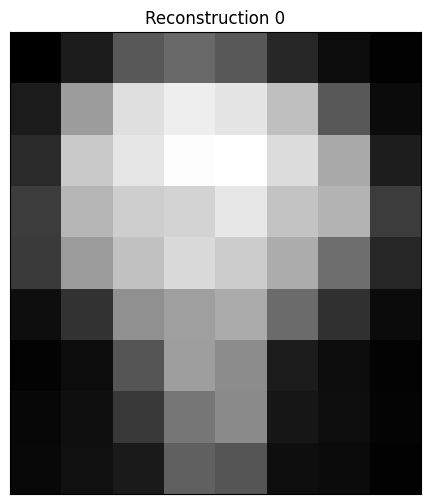

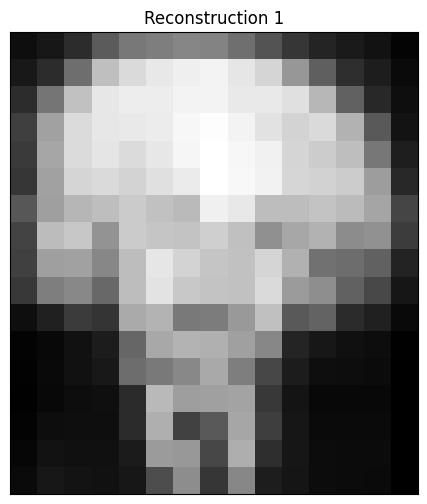

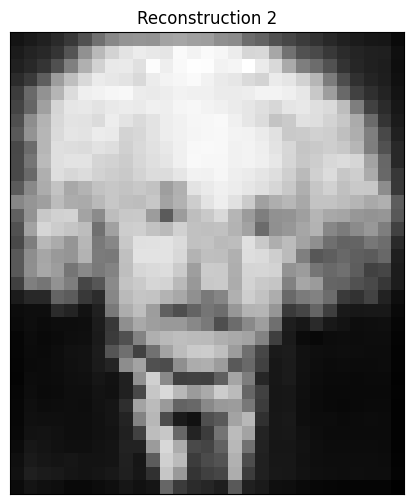

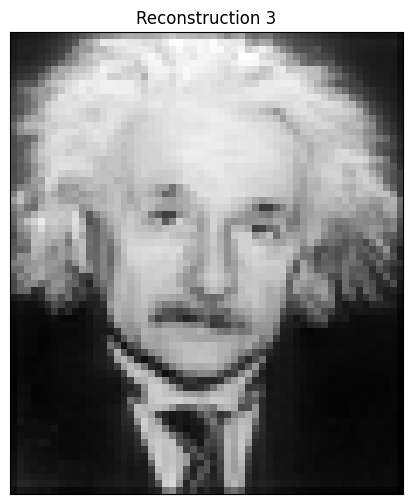

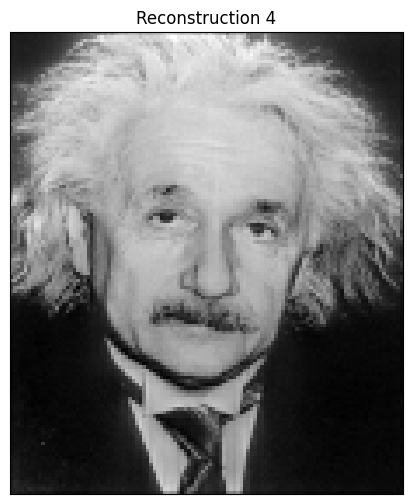

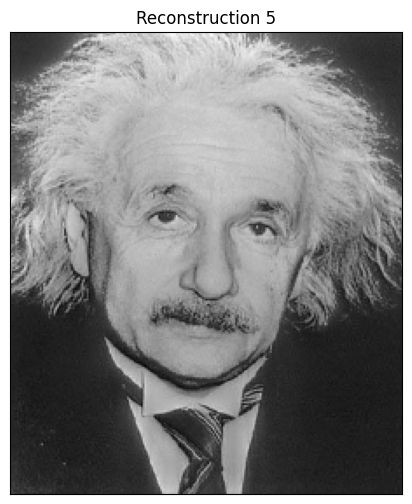

In [ ]:
def reconstructLap_pyrUp(L):
    cur = L[-1].astype(np.float64)
    rec = [cur]
    for i in range(len(L)-2, -1, -1):
        H, W = L[i].shape[:2]
        up = cv2.pyrUp(cur, dstsize=(W, H))
        cur = up + L[i]
        rec.append(cur)
    return rec


rec = reconstructLap_pyrUp(pyrL)
final = rec[-1]
print('Error per pixel',np.sqrt(np.mean((im - np.round(final)) ** 2)))
for i in range(len(rec)):
  displayIm(rec[i], f"Reconstruction {i}")

### APARTADO 3 (0.5 puntos)

Las herramientas de IA generativa son de gran utilidad tanto para estudiantes como para docentes. No obstante, resulta fundamental tener una actitud crítica y asumir desde el principio que las respuestas proporcionadas por estas herramientas pueden ser factualmente incorrectas (véase,  por ejemplo, https://elpais.com/tecnologia/2024-09-25/los-nuevos-modelos-de-ia-como-chatgpt-persiguen-la-superinteligencia-pero-no-logran-ser-fiables-ni-en-preguntas-bobas.html o https://maldita.es/malditobulo/20250827/grok-identifica-mal-fotografia-franquismo/). En este sentido, vale la pena recordar lo que indica la guía de la UGR (https://ceprud.ugr.es/formacion-tic/inteligencia-artificial): _"Debes revisar siempre la salida que genera y las posibles referencias que utilice. [...] Mejora tus resultados con la IAGen aprendiendo a usarla y a comunicarte con ella de manera adecuada. Pero no dejes que piense por ti."_

En este apartado trabajaremos de forma crítica la utilidad de estas herramientas. Para ello, el alumnado debe emplear ChatGPT (https://chatgpt.com/) para analizar si es posible reconstruir a la perfección (`Error per pixel 0.0`) la imagen original por medio de una pirámide Laplaciana construida a partir de una pirámide Gaussiana sin suavizado (es decir, una pirámide no realmente Gaussiana, construida exclusivamente en base a hacer subsampling). Deben indicarse tanto los prompts empleados, como los razonamientos o experimentos llevados a cabo para concluir si lo que la herramienta de IA afirmaba era correcto o no. Muy importante: no se trata meramente de copiar lo que indique ChatGPT como salida, sino de analizar y matizar su respuesta, confrontándola con otras lecturas y lo que el estudiante sabe de la teoría, indicando en qué aspectos dicha respuesta puede considerarse correcta y en qué aspectos quizás no lo es.

<font color="blue">Antes de preguntar a la IA, vamos a comprobar que pasa si no usamos suavizado:

Error per pixel 0.0


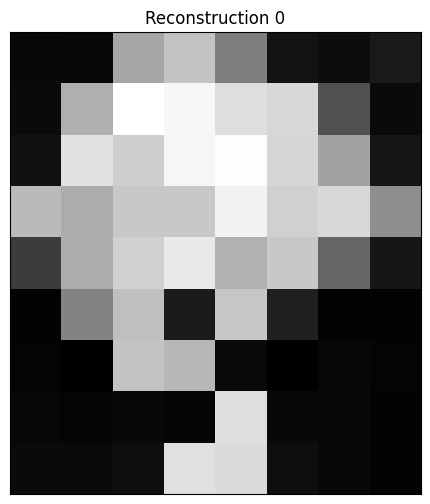

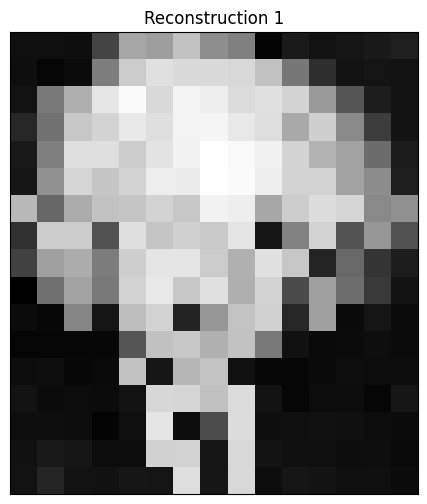

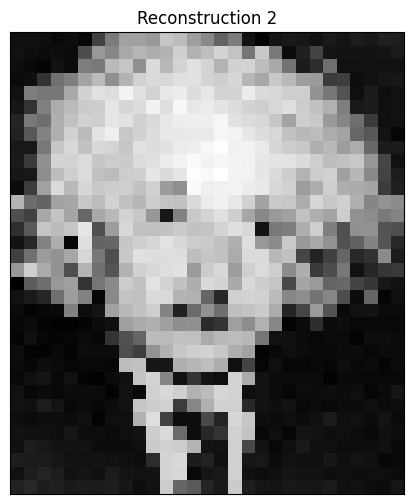

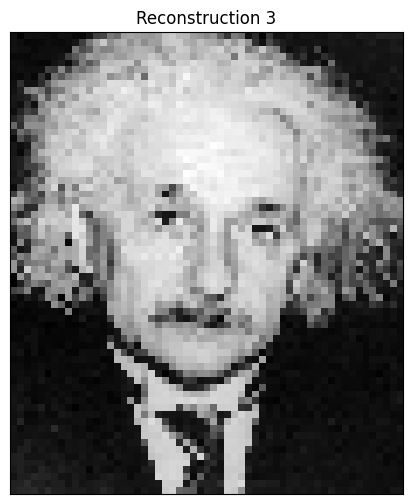

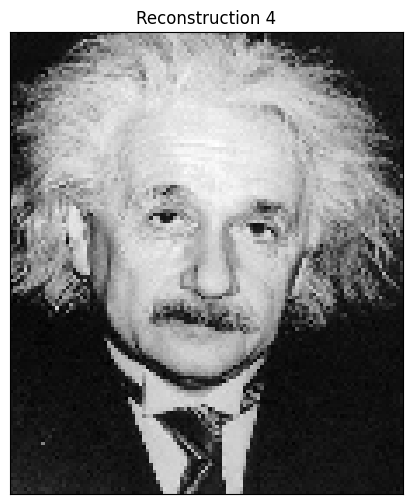

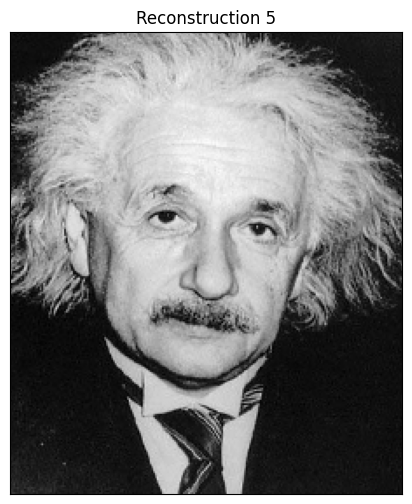

In [ ]:
def pyramidGauss_SinSuavizado(im,sizeMask=7, nlevel=4):
  #A CUBRIR POR EL ALUMNADO
  out = [im]
  for i in range(nlevel):
    #subsumple
    im_copia = im[::2, ::2]
    out.append(im_copia)
    im = im_copia

  return out#A CUBRIR POR EL ALUMNADO

def pyramidLap_SinSuavizado(im, sizeMask,nlevel=4,flagInterp=cv2.INTER_LINEAR  ):
  #A CUBRIR POR EL ALUMNADO
  G = pyramidGauss_SinSuavizado(im, sizeMask=sizeMask, nlevel=nlevel)

  L = []
  L_visual = []
  for i in range(len(G) - 1):
      Gi   = G[i]
      Gi1  = G[i + 1]
      H, W = Gi.shape[:2]
      up = cv2.resize(Gi1, (W, H), interpolation=flagInterp)
      L.append(Gi - up)
      L_visual.append(rangeDisplay01(Gi - up))

  L.append(G[-1])
  L_visual.append(rangeDisplay01(G[-1]))
  return L, L_visual

im=cv2.imread(get_image('einstein.bmp'),0).astype(np.float64)

pyrL_SinSuavizado, pyrLvisual_SinSuavizado = pyramidLap_SinSuavizado(im,sizeMask=5, nlevel=5)

rec_SinSuavizado = reconstructLap(pyrL_SinSuavizado, cv2.INTER_LINEAR)
final = rec_SinSuavizado[-1]
print('Error per pixel',np.sqrt(np.mean((im - np.round(final)) ** 2)))
for i in range(len(rec_SinSuavizado)):
  displayIm(rec_SinSuavizado[i], f"Reconstruction {i}")

<font color="blue">Como podemos ver, la reconstrucción es muy mala, con un error de casi 550 por pixel cuando la imagen no la leemos como np.float64 en cambio si indicamos que el tipo es ese, el error sale 0, completamente perfecta!. A priori tiene sentido porque al final al construir la pirámide Gaussiana al final lo que tenemos es una serie de imágenes, y par construir la Laplaciana y luego recuperar las imágenes orignales es pura aritmética, así que cuando usamos float64 al no perderse precisión por errores de redondeo el error es 0. Ahora le vamos a preguntar a ChatGpt pasandole el código anterior y pidiendole que indique porque no se obtiene una reconstrucción perfecta en el primer caso y si en el segundo.

<font color="blue">Efectivamente ha confirmado que tiene sentido que de error 0 ya que es simplemente cuestión de despejar de la ecuación $a-b=c$, y dice lo siguente respecto a no usar float64 en las imágenes, que de nuevo es una expliación acorde con lo ya visto en clase:

<font color="blue">¿Por qué no se reconstruye bien con uint8?

<font color="blue">La clave: una pirámide Laplaciana necesita guardar valores con signo (positivos y negativos).
Con uint8 (rango 0…255) esto es imposible y “revienta” por dos vías.

<font color="blue">1) La resta de la Laplaciana pierde la parte negativa

<font color="blue">Definición de la capa Laplaciana:
\begin{equation}
L_i = G_i - Up(G_{i+1})
\end{equation}

<font color="blue">Si $G_i$ y $Up(G_{i+1})$ son uint8, la operación $G_i - Up(G_{i+1})$ en NumPy también es uint8:

  <font color="blue">-> Los negativos hacen wrap (aritmética módulo 256). Ejemplo: 10 - 200 = 66 (porque $-190 mod 256 = 66$).

  <font color="blue">v-> En OpenCV, cv2.subtract(Gi, up) con uint8 no hace wrap, pero satura en 0: 10 - 200 = 0.

<font color="blue">En ambos casos se pierde la información negativa del residuo, justo la que necesitas para reconstruir.

<font color="blue">2) La suma en reconstrucción puede desbordar

<font color="blue">Durante la reconstrucción:
\begin{equation}
G_i = L_i + \operatorname{Up}(G_{i+1})
\end{equation}

<font color="blue">Con uint8 en NumPy: 250 + 10 = 4 (por wrap en 256).

<font color="blue">Con cv2.add en uint8: 250 + 10 = 255 (por saturación).

<font color="blue">Otra vez, el valor correcto se pierde.

# **Ejercicio 3: Imágenes Híbridas** (1.5 puntos)

Este ejercicio se basa en el siguiente trabajo: $\textit{Oliva, A., Torralba, A., & Schyns, P. G. (2006). Hybrid images. ACM Transactions on Graphics (TOG), 25(3), 527-532}$ (https://stanford.edu/class/ee367/reading/OlivaTorralb_Hybrid_Siggraph06.pdf).

Vamos a profundizar un poco en cómo el sistema visual humano extrae información sobre un objeto en función de la distancia. Para ello, construimos una imagen híbrida a partir de dos imágenes de objetos diferentes. Mezclando adecuadamente parte de las altas frecuencias de una imagen con parte de las bajas frecuencias de la otra, obtenemos una imagen híbrida que muestra diferentes percepciones con la distancia.

El sigma empleado para filtrar ambas imágenes (tanto la de alta como la de bajas frecuencias) es el aspecto clave para seleccionar el rango de frecuencias altas y bajas de cada imagen. Cuanto mayor sea el valor sigma, mayor será la eliminación de altas frecuencias de la imagen. Se recomienda elegir este valor por separado para cada una de las imágenes y, de hecho, es deseable tener distintos valores para distintos pares de imágenes.

Aspectos de importancia en relación a este ejercicio:

1. Como mínimo, se deben generar las imágenes híbridas correspondientes a `'plane.bmp'+'bird.bmp'` y `'bicycle.bmp'+'motorcycle.bmp'` (ambas parejas en escala de grises). Y también el alumnado debe escoger, como mínimo, otro par de imágenes de su elección a hibridar en color, fuera de las incluidas en la carpeta compartida en Drive (https://drive.google.com/drive/folders/1UtvY8q6w1Cz9a9T9zxIqSweoRLgNwoW-). Es decir, como mínimo, debe haber $3$ pares de imágenes híbridas como parte de la respuesta a este ejercicio. Se debe emplear una pirámide Gaussiana con $5$ niveles para mostrar el efecto obtenido.

**Nota:** de cara a emplear imágenes que no estén en el repositorio compartido, se recomienda que el alumnado emplee un código como el que se muestra a continuación, y que permite descargar sobre la marcha imágenes a partir de una URL dada.






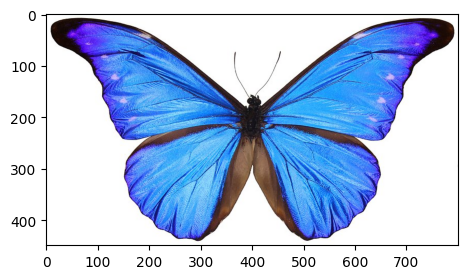

In [ ]:
import requests
def downloadImage(url):
    response = requests.get(url)
    img_array = np.frombuffer(response.content, np.uint8)
    img = cv2.imdecode(img_array, cv2.IMREAD_COLOR)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = img.astype(np.float64)/255
    return img
try:
    smiley_im = downloadImage("https://images.rawpixel.com/image_800/cHJpdmF0ZS9sci9pbWFnZXMvd2Vic2l0ZS8yMDIyLTA1L2ZsMTI5Mjk0MTAxNjUtaW1hZ2Uta3liZW9jNjEuanBn.jpg")
    plt.imshow(smiley_im)
except:
    print("Couldn't download the image from the given URL")

2. No es necesario seguir al pie de la letra el artículo de referencia y operar en el dominio de la frecuencia (Fourier). Basta con operar en el dominio del espacio, como hemos hecho en todos los demás apartados de esta práctica. No obstante, sí se debe emplear/buscar algún criterio objetivable/cuantificable a la hora de escoger qué imagen se empleará para las altas frecuencias y cuál para las bajas frecuencias. No basta con escogerla "a ojo" y, al contrario, se debe definir alguna métrica que permita realizar la selección.

3. En relación con el punto anterior, se debe explicar con claridad el proceso seguido para filtrar la imagen de altas frecuencias y la de bajas frecuencias, incluyendo la elección de los sigmas finalmente utilizados. La realización de una experimentación preliminar, por medio de prueba y error, es perfectamente válida, pero hay que explicarla y justificarla de algún modo. No basta con probar una serie de valores arbitrarios y justificarlo, sucintamente, indicando que *"se procedió por medio de prueba y error hasta obtener el sigma final"*.

<font color="blue">Primero una breve explicación: Las bajas frecuencias corresponden a grandes y suaves estructuras mientras que las altas frecuencias representan detalle pequeños o bordes.

<font color="blue">Esto significa que las cosas (colores, brillo) que cambian lentamente a través de la imagen (es decir, están extendidas y son grandes) corresponden a componentes de baja frecuencia, mientras que las cosas que cambian rápidamente (es decir, detalles finos que solo existen en pequeñas ubicaciones espaciales) corresponden a componentes de alta frecuencia. Es decir, alta frecuencia corresponde a detalle, baja frecuencia corresponde a características grandes.

<font color="blue">Ejemplo: Imaginate que esto fuera una imagen: |||||. Si te mueves a lo largo del eje x, los valores de los píxeles cambian rápido y periódicamente, esto es una alta frecuencia. Si te mueves a lo largo del eje y, los píxeles no cambian para nada y por lo tanto no tiene frecuencias en la dimensión y.

<font color="blue">Es por ello que un criterio objetivable/cuantificable a la hora de escoger qué imagen se empleará para las altas frecuencias y cuál para las bajas frecuencias es usar la energía de gradiente, que recordemos está relacionado con los mayores cambios de intensidad. La imagen con mayor energía de gradiente aporta altas; la otra aporta bajas.

<font color="blue">La función hace lo siguiente(con ayuda de ChatGpt):

<font color="blue">-> Sobel calcula el gradiente en x e y.

<font color="blue">-> np.hypot obtiene la magnitud del gradiente por píxel.

<font color="blue">-> El mean() devuelve una métrica escalar: cuanto mayor, más contenido de alta frecuencia.

In [ ]:
def edge_energy(im_gray_float64):
    gx = cv2.Sobel(im_gray_float64, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(im_gray_float64, cv2.CV_64F, 0, 1, ksize=3)
    mag = np.hypot(gx, gy)
    return mag.mean()

<font color="blue">**Funcion hybrid_images**

<font color="blue">Recibe las dos imágenes a hibridar, los correspondientes sigmas, y el número de niveles y tamaño del kernel para la pirámide Gaussiana.

<font color="blue">Lo que hace es primero asegurarse que el tamaño de ambas imágenes es el mismo, luego a la de baja frecuencias la suaviza y a la de alta frecuencias le calcula la diferencia entre la imagen y correspondiente suavizada. Luego hibrida ambas haciendo uso de rangeDisplay01, ya que por ejemplo, en la imagen de la bici que tiene el fondo blanco, al hibridarla con cualquier imagen, con la moto por ejemplo, salvo que escalemos la suma de los píxeles de ambas imágenes, el fondo de la imagen hibridada siempre se va a ver muy brillante.

<font color="blue">Por último creamos la pirámide Gaussiana a partir de la imagen hibridada.

<font color="blue">**Plane and Bird**

<font color="blue">Empiezo con sigma_low = 7 y sigma_high = 2. En la imagen del pájaro se detectan demasiado los bordes, mientras que el avión si parece correcto. Probamos a subir el sigma_high = 3, y vemos que ya el pájaro se aprecia mejor e incluso mejora con sigma_high=4. A pesar de ello, se sigo viendo demasiado nítido en las imágenes más pequeñas de la pirámide, por lo que vamos a probar a subir el tamaño de sizeMask de 5 a 10, para que en consecuencia aumente el sigma(distinto del usado en la hibridación). Con esto conseguimos el resultado esperado.

<font color="blue">**Bicycle and motorcycle**

<font color="blue">Empezamos con sizeMask = 10, sigma_low = 7 y sigma_high = 5. La bici todavía puede estar un poco más difuminada así que subimos sigma_low = 10. La moto por el contrario si parece correcta.





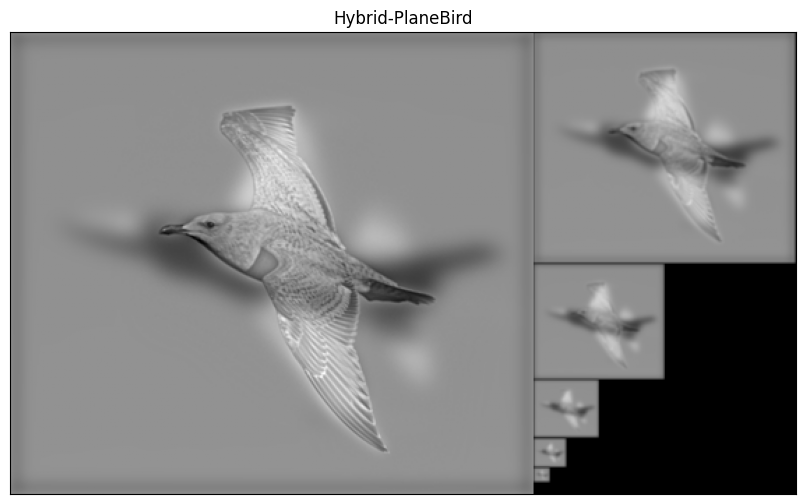

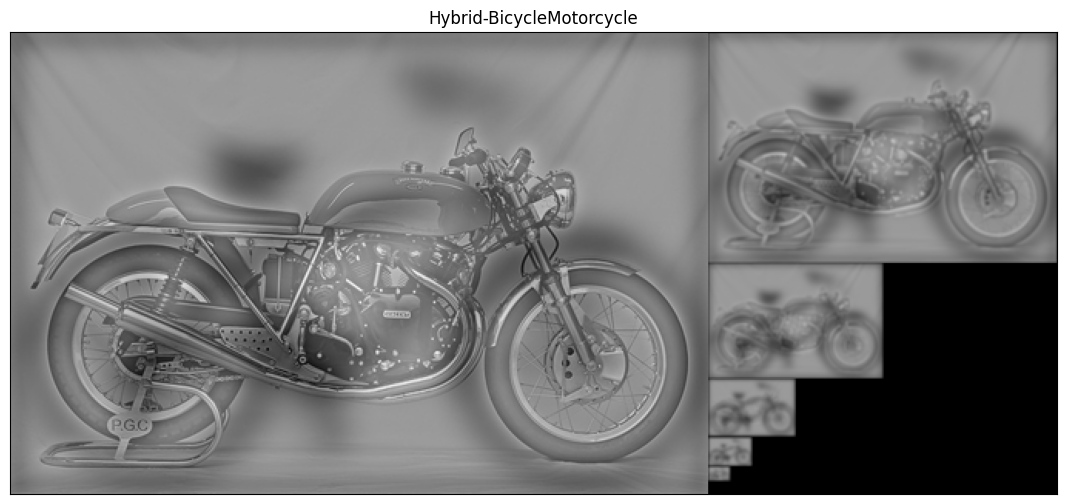

In [ ]:
def hybrid_images(low_freq_im, high_freq_im, sigma_low, sigma_high, nlevel=5, sizeMask=5):
    # work in float64 [0,255]
    A = low_freq_im.astype(np.float64)
    B = high_freq_im.astype(np.float64)
    H, W = A.shape[:2]
    if B.shape[:2] != (H, W):
        B = cv2.resize(B, (W, H), interpolation=cv2.INTER_LINEAR)

    gL = gaussianMask1D(sigma=sigma_low,  sizeMask=0, order=0)
    gH = gaussianMask1D(sigma=sigma_high, sizeMask=0, order=0)

    low  = convolve2D_any(A, gL, gL)
    high = B - convolve2D_any(B, gH, gH)
    hybrid = 255*rangeDisplay01(low + high)

    return pyramidGauss(hybrid, sizeMask=sizeMask, nlevel=nlevel)


plane=cv2.imread(get_image('plane.bmp'),0).astype(np.float64)
bird=cv2.imread(get_image('bird.bmp'),0).astype(np.float64)
pyrG = hybrid_images( plane, bird, 7,4, nlevel=5, sizeMask=10)
displayPyramid(pyrG,'Hybrid-PlaneBird')

bicycle=cv2.imread(get_image('bicycle.bmp'),0).astype(np.float64)
motorcycle=cv2.imread(get_image('motorcycle.bmp'),0).astype(np.float64)
pyrG = hybrid_images(bicycle, motorcycle, 10, 5, nlevel=5, sizeMask=10)
displayPyramid(pyrG,'Hybrid-BicycleMotorcycle')

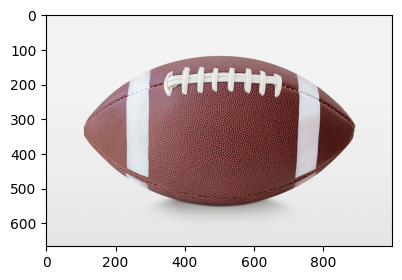

In [ ]:
try:
    rugby_im = downloadImage("https://images.rawpixel.com/image_social_landscape/czNmcy1wcml2YXRlL3Jhd3BpeGVsX2ltYWdlcy93ZWJzaXRlX2NvbnRlbnQvbHIvcGYtczYyLXBvbS0wNTU4LXBvbS5qcGc.jpg")
    plt.imshow(rugby_im)
except:
    print("Couldn't download the image from the given URL")

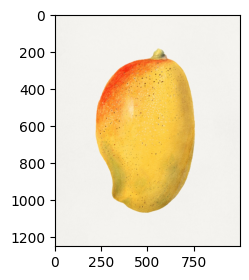

In [ ]:
try:
    mango_im = downloadImage("https://images.rawpixel.com/image_social_square/czNmcy1wcml2YXRlL3Jhd3BpeGVsX2ltYWdlcy93ZWJzaXRlX2NvbnRlbnQvbHIvcGR3YXRlcmNvbG9yZnJ1aXRiYXRjaDEtNjYxLWdsb3ktYV8xLmpwZw.jpg")
    plt.imshow(mango_im)
except:
    print("Couldn't download the image from the given URL")

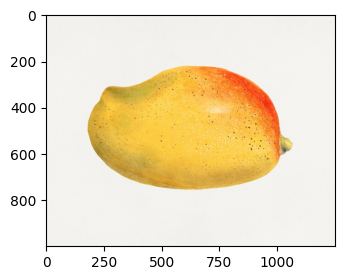

In [ ]:
h, w = mango_im.shape[:2]
if h > w:
    mango_im_rot = cv2.rotate(mango_im, cv2.ROTATE_90_CLOCKWISE)

plt.imshow(mango_im_rot)

In [ ]:
print(f"Energia del gradiente de la imagen rubgy: {edge_energy(rugby_im)}\n")
print(f"Energia del gradiente de la imagen mango: {edge_energy(mango_im_rot)}\n")

Energia del gradiente de la imagen rubgy: 0.24107157776511656

Energia del gradiente de la imagen mango: 0.07048944726969532



<font color="blue">Hemos empezado con sigma_low = 7 y sigma_high=3. para obtener más grado de detalle en rugby y que mango salga más difuminado hemos aumentado ambos valores a 5 y 15 respectivamente.

<font color="blue">Noralizamos a [0,1] antes de visualizar ya que tenía el siguiente error:

<font color="blue">*Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].*

<font color="blue">De acuerdo con ChatGpt, esto significa que muestro arrays float con valores 0..255. Para imshow, si el tipo es float, espera 0..1. Como tus niveles están en 0..255, imshow los “recorta” a [0,1] y prácticamente todo queda en 1 → blanco.

<font color="blue">Que efectivamente era la imagen que me salía: todo blanco

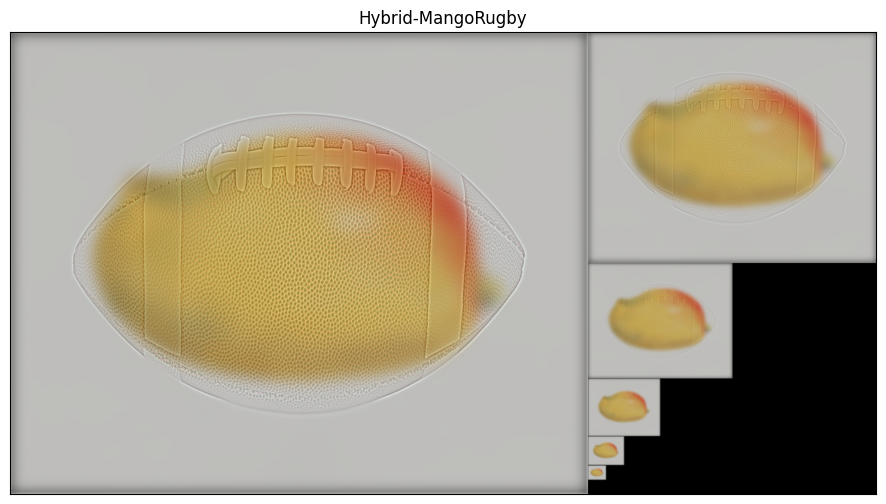

In [ ]:
pyrG = hybrid_images(mango_im_rot, rugby_im, 15, 3, nlevel=5, sizeMask=10)
pyrG_01 = [np.clip(x/255.0, 0.0, 1.0) for x in pyrG]
displayPyramid(pyrG_01, 'Hybrid-MangoRugby')

# **Ejercicio 4: Canny Edge Detector** (1.5 puntos)

En este ejercicio se debe implementar el algoritmo de detección de bordes de Canny y evaluarlo con la imagen `cat.bmp`. Para ello, se deben emplear las funciones definidas hasta ahora en los ejercicios anteriores (de generación de kernels Gaussianos y convolución separable) para:

1. **Suavizar la imagen de entrada** para reducir el impacto del ruido. Se debe definir un $sigmaS$, que controlará el grado de suavizado de la imagen de entrada, cuyo valor debe ajustarse adecuadamente.

2. Ahora debemos filtrar la imagen con derivadas de la Gaussiana, y **calcular la magnitud y orientación del gradiente**. Los códigos del ejercicio 1.C nos servirán de gran utilidad a este respecto. Es importante destacar que la orientación que queremos calcular debe estar en $[0,180)$ grados en lugar de $[0,360]$, dado que el gradiente de un borde no tiene una dirección específica en el sentido de "ida y vuelta". Es decir, lo que nos importa es la orientación del borde, y no el sentido del flujo de píxeles a través de él. Se debe definir un $sigmaG$, cuyo valor debe ajustarse adecuadamente.

3. ***Non-maximum suppression***. Este es uno de los elementos clave del algoritmo. En aras de simplificar y acelerar la ejecución de nuestra implementación, lo primero que hacemos es emplear $4$ posibles clusters de ángulos ($0$, $45$, $90$, $135$) a través del siguiente *mapping*:
```
    [0,22.5) U [157.5,180) -> sector 0
    [22.5,67.5) -> sector 45
    [67.5,112.5) -> sector 90
    [112.5,157.5) -> sector 135
```
De esta manera estamos discretizando los valores de los posibles ángulos/direcciones de cada pixel. Recordemos que la dirección del gradiente es perpendicular al borde. De modo que un píxel perteneciente a un borde vertical tendría un gradiente con orientación $0º$. A continuación, debemos seleccionar los vecinos de cada píxel basándonos en su orientación:
- si dicho píxel pertenece al sector de $0º$, lo compararemos con su vecino izquierdo y derecho.
- si dicho píxel pertenece al sector de $45º$, lo compararemos con su vecino de arriba a la derecha y de abajo a la izquierda.
- si dicho píxel pertenece al sector de $90º$, lo compararemos con su vecino de arriba y de abajo.
- si dicho píxel pertenece al sector de $135º$, lo compararemos con su vecino de arriba a la izquierda y de abajo a la derecha.

Y, en todos los casos, si el píxel tiene mayor magnitud que sus vecinos, nos lo quedaremos (de lo contrario, lo ignoraremos y no pasará a la siguiente etapa).

Con el fin de obtener una implementación de eficiencia razonable, cuyo tiempo de ejecución no difiera notablemente del que ofrece OpenCV, se plantea la siguiente alternativa (que se plantea, en todo caso, como una mera sugerencia, dado que el alumnado tiene libertad para escoger su propia solución):  

- Construir todas las matrices de vecinos (`up`, `down`, `left`, `right`,  `up_left`, etc.) a partir de la imagen de magnitudes original. Y, para realizar las comparaciones, se deben utilizar estos arrays directamente. Es decir, se recomienda emplear operaciones vectorizadas y rehuir de bucles `for` en la medida de lo posible.

- Para cada sector, la decisión de "mantener/descartar" un píxel depende solo de la magnitud del gradiente original y de las dos entradas vecinas precomputadas. No se debe modificar ni la magnitud del gradiente ni los vecinos durante la iteración. De este modo, por ejemplo, procesar el sector $0$ antes o después de sector $45$ no cambia nada.

4. **Umbralización e histéresis**. Se definen dos umbrales ($low$ y $high$). Tras el *non-maxima suppression*, nos interesa quedarnos los píxeles con valores iguales o mayores que $high$. También nos interesa descartar los que sean menores que $low$. Ahora aplicamos la histéresis, que se basa en "promover a fuerte todo píxel débil que esté conectado por una cadena de píxeles débiles (o fuertes) a un píxel fuerte". Para implementar esta sección se recomienda emplear `cv2.connectedComponents()` con `connectivity=8`. Pensemos que, si una componente conexa contiene al menos un píxel $strong$, entonces toda la componente conexa estará conectada/encadenada a dicho píxel.

Una vez haya finalizado la implementación, verifique el comportamiento del algoritmo estudiando cómo varían las salidas si se modifican los umbrales $low$, $high$, $sigmaS$ y $sigmaG$.





In [ ]:
import cv2
import numpy as np

def gradient_and_angle(img, sigmaG):
  #A CUBRIR POR EL ALUMNADO
  dx = my2DConv(img, sigmaG, [1, 0])
  dy = my2DConv(img, sigmaG, [0, 1])

  mag = np.sqrt(dx*dx + dy*dy)            # magnitud
  ori = np.arctan2(dy, dx)                # orientación en radianes (-pi, pi]
  ori = (ori + np.pi) % np.pi

  return dx, dy, mag, ori

In [ ]:
#Para construir las matrices de vecinos y poder comparar cada pixel con los
#dos vecinos que le tocan segun su orientacion
def _shift(arr, dy, dx):
  #The np.zeros_like function in NumPy creates a new array filled with zeros,
  #having the same shape, size, and data type as a given input array
  out = np.zeros_like(arr)
  H, W = arr.shape
  y0 = max(0, dy); y1 = H + min(0, dy)
  x0 = max(0, dx); x1 = W + min(0, dx)
  out[y0:y1, x0:x1] = arr[y0-dy:y1-dy, x0-dx:x1-dx]
  return out

def non_maximum_suppression(mag, ang):
  #A CUBRIR POR EL ALUMNADO
  H, W = mag.shape

  # Construir todas las matrices de vecinos (up, down, left, right, up_left, etc.)
  #a partir de la imagen de magnitudes original.
  L   = _shift(mag, 0, -1); R   = _shift(mag, 0, 1)
  U   = _shift(mag,-1,  0); D   = _shift(mag, 1, 0)
  UL  = _shift(mag,-1, -1); UR  = _shift(mag,-1, 1)
  DL  = _shift(mag, 1, -1); DR  = _shift(mag, 1, 1)

  # sectores
  s0   = (ang < 22.5) | (ang >= 157.5)        # 0°
  s45  = (ang >= 22.5) & (ang < 67.5)         # 45°
  s90  = (ang >= 67.5) & (ang < 112.5)        # 90°
  s135 = (ang >=112.5) & (ang < 157.5)        # 135°

  out = np.zeros_like(mag)

  # comparar con vecinos adecuados
  #si pertenece al sector de  0º, lo compararemos con su vecino izquierdo y derecho.
  m0   = s0   & (mag >= L)   & (mag >= R)
  #si pertenece al sector de  45º , lo compararemos con su vecino de arriba a la derecha y de abajo a la izquierda.
  m45  = s45  & (mag >= UR)  & (mag >= DL)
  #si pertenece al sector de  90º , lo compararemos con su vecino de arriba y de abajo.
  m90  = s90  & (mag >= U)   & (mag >= D)
  #si pertenece al sector de  135º , lo compararemos con su vecino de arriba a la izquierda y de abajo a la derecha.
  m135 = s135 & (mag >= UL)  & (mag >= DR)

  keep = m0 | m45 | m90 | m135
  out[keep] = mag[keep]

  return out

<font color="blue">The cv2.connectedComponents() function in OpenCV is used to perform connected component labeling on a binary image, assigning a unique label to each connected region of foreground pixels.
 It returns a tuple containing the number of labels (including the background label) and a labeled image where each pixel is assigned a label corresponding to its connected component.
 The function supports both 4-way and 8-way connectivity, with 8-way being the default; 4-way connectivity considers only the top, bottom, left, and right neighbors, while 8-way connectivity also includes diagonal neighbors.

 <font color="blue">The np.isin function in NumPy checks whether each element of an input array (element) is present in a set of test values (test_elements) and returns a boolean array of the same shape as element, where True indicates the corresponding element is found in test_elements.

In [ ]:
def double_threshold_and_hysteresis_fast(nms, low, high):
    #A CUBRIR POR EL ALUMNADO
    #nos interesa quedarnos los píxeles con valores iguales o mayores que  ℎ𝑖𝑔ℎ .
    #También nos interesa descartar los que sean menores que  𝑙𝑜𝑤 .
    strong = nms >= high
    weak   = (nms >= low) & ~strong
    #los que no son ni strong ni weak son los que descartamos

    # Pensemos que, si una componente conexa contiene al menos un píxel  𝑠𝑡𝑟𝑜𝑛𝑔 ,
    #entonces toda la componente conexa estará conectada/encadenada a dicho píxel.
    mask = strong | weak
    num, labels = cv2.connectedComponents(mask.astype(np.uint8), connectivity=8)

    # etiquetas (id) que tienen al menos 1 píxel fuerte
    strong_labels = np.unique(labels[strong])
    # mantener toda componente conexa que toque un fuerte
    #labels es la imagen de componentes conexas (0 = fondo, 1,2,3… = id de componente).
    keep = np.isin(labels, strong_labels) & (labels != 0)

    # salida binaria (0/255)
    return (keep.astype(np.uint8) * 255)


<font color="blue">**Una vez haya finalizado la implementación, verifique el comportamiento del algoritmo estudiando cómo varían las salidas si se modifican los umbrales  𝑙𝑜𝑤 ,  ℎ𝑖𝑔ℎ ,  𝑠𝑖𝑔𝑚𝑎𝑆  y  𝑠𝑖𝑔𝑚𝑎𝐺 .**

<font color="blue">*sigmaS:* Este sigma es el que afecta al suavizado previo, como hemos visto en clase, cuanto mayor es este valor menos detalle queda, es por ello que con valores cercanos a 0, como 0.5 se aprecian un monton los detalles y los bordes son muchos, en cambio con un sigmaS de 2 la imagen se aprecia mucho mejor.

<font color="blue">*sigmaG:* nos indica la precisión al calcular el gradiente, a mayor valor, bordes más gruesos y magnitudes más suaves, como con sigmaG = 1.5. Mientras que si baja es gradiente es más sensible a detalles y a ruido, como sigmaG = 0.5. Nos vamos a quedar con un valor intermedio, sigmaG = 1.

<font color="blue">*high:* Tras NMS, nos quedamos con las componentes conexas que tengan al menos un pixel fuerte, que se tiene cuando su valor es mayor que es parámetro, por lo que su lo aumentamos, hay menos píxeles fuertes y por tanto menos bordes(solo las componentes conexas que tienen al menos un fuerte se ponen a 255, i.e., blanco, si no se mantienen a 0, i.e., negro, por lo que no se muestra ningún borde). Por el contrario al bajar este parámetro habrá más píxeles fuertes y en consecuencia más bordes.

<font color="blue">*low:* Tras NMS, todos los píxeles con valor menos que low no se tienen en cuenta, es decir pasan a ser 0, i.e., negro. Los que están entre low y high, en caso de estar conectados a un pixel fuerte podrían volver a ser tenidos en cuenta. Es por ello que si subimos low, eliminamos cada vez más píxeles y al bajar pueden aparecer más bordes, si se baja mucho podría dar lugr a ruido.

<font color="blue">A la hora de elegir low y high hay que tener en cuenta también que nms es una imagen en coma flotante con:
0(negro) donde el píxel no es máximo local, y
donde si es máximo el valor de magnitud del gradiente.

<font color="blue">Con low=100 y high=200 la imagen sale entera negra, ya que no habra pixeles fuertes como para que aparezcan bordes blancos. Si vamos bajando los valores a low=50 y high=150 se sigue viendo negra la imagen. En low=25 y high=50 empiezan a aparecer los primeros bordes y no es hasta que low=2 y high=3 que podemos ver el resultado correctamente.

In [ ]:
def my_canny(img, low_thresh, high_thresh, sigmaGradient, sigmaSmoothing):
    #A CUBRIR POR EL ALUMNADO
    imgf = img.astype(np.float64)

    # suavizado previo (sigmaS)
    gS = gaussianMask1D(sigma=sigmaSmoothing, sizeMask=0, order=0).astype(np.float64)
    image_smooth = convolve2D(imgf, gS, gS)

    # gradiente y orientación (sigmaG)
    _, _, mag, ang = gradient_and_angle(image_smooth, sigmaGradient)

    # NMS
    nms = non_maximum_suppression(mag, ang)

    # doble umbral + histéresis
    edges = double_threshold_and_hysteresis_fast(nms, low_thresh, high_thresh)
    return nms, edges



img=cv2.imread(get_image('cat.bmp'),0).astype(np.float32)
sigmaG = 3 #A CUBRIR POR EL ALUMNADO
sigmaS = 2 #A CUBRIR POR EL ALUMNADO
high = 3 #A CUBRIR POR EL ALUMNADO
low  = 2 #A CUBRIR POR EL ALUMNADO
nms, edges = my_canny(img, low_thresh=low, high_thresh=high, sigmaGradient=sigmaG, sigmaSmoothing = sigmaS)

displayIm(rangeDisplay01(img), title='Original',factor= 2)
displayIm(edges, title='Mi Implementación de Canny',factor= 2)
#displayMI_ES([rangeDisplay01(img), edges], title='Original vs Mi Implementación de Canny')